# Analysis of T0 vs. Plasmid condition

- Will also analyze DMSO vs. T0/DMSO vs. Plasmid conditions
- Looking in the absence of drug at the behavior of gRNAs targeting different tCDKs

In [1]:
import pandas as pd 
import numpy as np 
import seaborn as sns 
import matplotlib.pyplot as plt 
import scipy.stats
import os
from adjustText import adjust_text
import matplotlib.patheffects as PathEffects
import warnings
warnings.filterwarnings('ignore')
plt.rc('font', family='Helvetica')

In [2]:
CBE_counts = pd.read_csv('MAGeCK/CDK_bc_counts.txt', sep='\t')
ABE_counts = pd.read_csv('MAGeCK/ABE_CDK_bc_counts.txt', sep='\t')

#selecting relevant columns
CBE_counts = CBE_counts[['sgRNA', 'gene', 'Plasmid', 'T0_REP1', 'T0_REP2', 'DMSO_REP1', 'DMSO_REP2', 'DMSO_REP3']].rename(columns={'sgRNA':'gRNA_id'})
ABE_counts = ABE_counts[['sgRNA', 'gene', 'Plasmid', 'T0_REP1', 'T0_REP2','T0_REP3','DMSO_REP1', 'DMSO_REP2', 'DMSO_REP3']].rename(columns={'sgRNA':'gRNA_id'})

In [3]:
#adding in CBE T0 REP3 data
fp = 'ABE_screen_data/ABE_counts'
k = ['D24-295031-1-7018H_guide_split_BARCODES_count_df.csv',
     'D24-295031-2-7018H_guide_split_BARCODES_count_df.csv']

df = pd.read_csv('CDK_library_final.csv')
pool1 = list(df[df['Pool']=='F1-R1']['gRNA_id'])
pool2 = list(df[df['Pool']=='F2-R2']['gRNA_id'])
pool3 = list(df[df['Pool']=='F3-R3']['gRNA_id'])

name_dict = {'D24-295031' : 'T0_REP3_CBE'} 

new_name = []
df_holder = []
for i, val in enumerate(k):
    n = name_dict[val[:10]] + '_' + val[11]
    new_name.append(n)
    a = pd.read_csv(f'{fp}/{val}')

    a_pool1 = a[a['Guide_ID'].isin(pool1)]
    a_pool2 = a[a['Guide_ID'].isin(pool2)]
    a_pool3 = a[a['Guide_ID'].isin(pool3)]

    df_holder.append(a_pool1)
    print(f'{n}: pool1: {sum(a_pool1["bc_count"])}, pool2:{sum(a_pool2["bc_count"])}, pool3: {sum(a_pool3["bc_count"])}')

count_dict = dict(zip(new_name, df_holder))

bc_counts_combined = []

for i in name_dict.values():
    flow1 = count_dict[i+'_1']
    flow2 = count_dict[i+'_2']

    c = np.asarray(flow1['bc_count']) + np.asarray(flow2['bc_count'])
    bc_counts_combined.append(c)

    assert list(flow1['Guide_ID']) == list(count_dict[new_name[0]]['Guide_ID'])

count_df  = pd.DataFrame(dict(zip(name_dict.values(), bc_counts_combined)))
count_df_w_gRNA_name = count_df.copy()
count_df_w_gRNA_name['gRNA_id'] = list(count_dict[new_name[0]]['Guide_ID'])


gene_name = []
for i, val in count_df_w_gRNA_name.iterrows():
    gid = val['gRNA_id']
    subset = df[df['gRNA_id']==gid]

    if subset['classification'].values[0]=='intron':
        gene_name.append(subset['Gene'].values[0] + '_intron')
    elif subset['classification'].values[0]=='non-targeting control':
        gene_name.append('NT')
    elif subset['classification'].values[0]=='targeting':
        gene_name.append(subset['Gene'].values[0])

count_df_w_gRNA_name['gene'] = gene_name

T0_REP3_CBE_1: pool1: 8342904.0, pool2:1989.0, pool3: 562.0
T0_REP3_CBE_2: pool1: 8395021.0, pool2:2070.0, pool3: 597.0


In [4]:
print(list(CBE_counts['gRNA_id']) == list(count_df_w_gRNA_name['gRNA_id']))

CBE_counts['T0_REP3'] = count_df_w_gRNA_name['T0_REP3_CBE']
CBE_counts = CBE_counts[['gRNA_id', 'gene', 'Plasmid', 'T0_REP1', 'T0_REP2','T0_REP3','DMSO_REP1', 'DMSO_REP2', 'DMSO_REP3']]

True


# transform to RPM values

With pseudocount of +1

In [5]:
samples = list(CBE_counts.columns[2:])

CBE_RPM = CBE_counts.copy()

#add pseudocount of 1 to each sample
#and normalize + calculate RPM
pseudocount = 1
for k in samples:
    col = np.asarray(CBE_counts[k]) + pseudocount
    sum_col = np.sum(col)
    rpm = 1e6*(col/sum_col)
    CBE_RPM[k] = rpm


#and do the same for ABE
ABE_RPM = ABE_counts.copy()

pseudocount = 1
for k in samples:
    col = np.asarray(ABE_counts[k]) + pseudocount
    sum_col = np.sum(col)
    rpm = 1e6*(col/sum_col)
    ABE_RPM[k] = rpm

In [6]:
import numpy as np
from scipy.stats import combine_pvalues
from statsmodels.stats.multitest import multipletests


def one_sided_FDR(condition_of_interest, LFC_df):
    # null distribution from NT-gRNAs (e.g., log2 fold changes)
    samp_of_interest = [f'{condition_of_interest}_REP{i}' for i in range(1,4)]


    #furthermore, add in the intron-targetting gRNAs to the distribution
    introns_NT = ['CDK19_intron', 'CDK9_intron', 'CDK7_intron', 'CDK8_intron', 'NT']

    non_targ = LFC_df[LFC_df['gene'].isin(introns_NT)].reset_index(drop=True)
    #non_targ = LFC_df[LFC_df['gene'].isin(['NT'])].reset_index(drop=True)

    data = non_targ[samp_of_interest].to_numpy().flatten()
    nt_gRNA_values = data
    print(len(nt_gRNA_values))

    #targeting gRNAs with 3 replicates per guide
    #including NT gRNAs here for completeness even though they're in the null distribution
    gRNA_values = np.asarray(LFC_df[samp_of_interest])

    # Function to compute empirical two-tailed p-values
    def empirical_p_value(observed, null_distribution):
        S_high = sum(null_distribution >= observed)
        S_low = sum(null_distribution <= observed)
        N = len(null_distribution)

        # Compute two-sided p-value
        p_high = (S_high + 1) / (N + 1)
        p_low = (S_low + 1) / (N + 1)
        return p_high, p_low

    # Compute p-values for each replicate separately (two-tailed)
    p_values_high = np.array([
        [empirical_p_value(rep, nt_gRNA_values)[0] for rep in gRNA] 
        for gRNA in gRNA_values
    ])

    p_values_low = np.array([
        [empirical_p_value(rep, nt_gRNA_values)[1] for rep in gRNA] 
        for gRNA in gRNA_values
    ])

    # Combine p-values across replicates using Fisher's method
    combined_p_values_high = np.array([
        combine_pvalues(p_vals, method='fisher')[1] for p_vals in p_values_high
    ])
    
    combined_p_values_low = np.array([
        combine_pvalues(p_vals, method='fisher')[1] for p_vals in p_values_low
    ])

    # Adjust for multiple testing (Benjamini-Hochberg FDR)
    adjusted_p_values_high = multipletests(combined_p_values_high, method='fdr_bh')[1]
    adjusted_p_values_low = multipletests(combined_p_values_low, method='fdr_bh')[1]

    # Store results in the dataframe
    LFC_df[f'p_high_unadjusted_{condition_of_interest}'] = combined_p_values_high
    LFC_df[f'p_low_unadjusted_{condition_of_interest}'] = combined_p_values_low
    LFC_df[f'FDR_high_{condition_of_interest}'] = adjusted_p_values_high
    LFC_df[f'FDR_low_{condition_of_interest}'] = adjusted_p_values_low
    LFC_df[f'p_unadjusted_{condition_of_interest}'] = [min(combined_p_values_high[i], combined_p_values_low[i]) for i in range(len(combined_p_values_high))]
    LFC_df[f'FDR_{condition_of_interest}'] = [min(adjusted_p_values_high[i], adjusted_p_values_low[i]) for i in range(len(adjusted_p_values_high))]

    return LFC_df #, p_values_per_replicate

In [7]:
CBE_RPM

,gRNA_id,gene,Plasmid,T0_REP1,T0_REP2,T0_REP3,DMSO_REP1,DMSO_REP2,DMSO_REP3
0,gRNA_CDK7_targ_1,CDK7,645.734931,444.160959,213.905129,659.651609,607.967881,582.599577,1008.146071
1,gRNA_CDK7_targ_2,CDK7,557.858423,306.384072,427.491553,307.514849,470.529237,453.119784,430.883493
2,gRNA_CDK7_targ_3,CDK7,233.563698,223.583616,172.074911,197.244373,215.984116,221.074670,186.171203
3,gRNA_CDK7_targ_4,CDK7,461.631780,209.511697,260.409709,269.045626,819.617867,747.655972,1080.874142
4,gRNA_CDK7_targ_5,CDK7,141.472107,276.129444,201.316226,361.574861,342.289996,337.132922,240.176674
...,...,...,...,...,...,...,...,...,...
2725,gRNA_nt_8935,NT,510.185285,239.638398,153.802409,66.843263,244.283432,303.721853,269.315368
2726,gRNA_nt_8936,NT,227.534527,71.255085,28.338313,127.235165,258.730530,283.161195,177.706478
2727,gRNA_nt_8937,NT,440.609714,785.021235,1314.451536,3634.206666,285.818839,297.296647,511.417041
2728,gRNA_nt_8938,NT,250.344003,174.715677,217.968636,251.184915,248.086418,274.261095,283.660571


In [8]:
plasmid_median = np.asarray(CBE_RPM['Plasmid'])

conditions = ['T0', 'DMSO']

df_holder2 = []
for condition_of_interest in conditions:

#condition_of_interest = 'KI-CDK9d-32_1000nM'
    samp_of_interest = [f'{condition_of_interest}_REP{i}' for i in range(1,4)]

    #calculate log2fc
    lfc_list = []
    for k in samp_of_interest:
        col = CBE_RPM[k]
        lfc = np.log2(col/plasmid_median)

        lfc_list.append(lfc)

    lfc_table = pd.DataFrame(dict(zip(samp_of_interest, lfc_list)))
    lfc_table[f'LFC_avg_{condition_of_interest}'] = np.average(lfc_table[samp_of_interest], axis=1)
    lfc_table[f'LFC_median_{condition_of_interest}'] = np.median(lfc_table[samp_of_interest], axis=1)
    lfc_table['Plasmid_RPM'] = plasmid_median
    ids = CBE_RPM[['gRNA_id', 'gene']]

    LFC_df = pd.concat((ids, lfc_table), axis=1)
    LFC_df = one_sided_FDR(condition_of_interest, LFC_df)
    df_holder2.append(LFC_df)

873
873


In [9]:
combined_LFC = pd.concat(df_holder2, axis=1)
combined_LFC = combined_LFC.loc[:,~combined_LFC.columns.duplicated()].copy()
combined_LFC = combined_LFC.rename(columns = {'gene':'Gene'})


CBE = pd.read_csv('CBE_master_Z_table.csv')
edit_info = CBE[['gRNA_id', 'WT_perc', 'Top_HGVSp', 'Top_HGVSp_%', 'Codon_1']]
targ_CBE = pd.merge(combined_LFC, edit_info, on='gRNA_id')

In [10]:
plasmid_median = np.asarray(ABE_RPM['Plasmid'])

conditions = ['T0', 'DMSO']

df_holder3 = []
for condition_of_interest in conditions:

#condition_of_interest = 'KI-CDK9d-32_1000nM'
    samp_of_interest = [f'{condition_of_interest}_REP{i}' for i in range(1,4)]

    #calculate log2fc
    lfc_list = []
    for k in samp_of_interest:
        col = ABE_RPM[k]
        lfc = np.log2(col/plasmid_median)

        lfc_list.append(lfc)

    lfc_table = pd.DataFrame(dict(zip(samp_of_interest, lfc_list)))
    lfc_table[f'LFC_avg_{condition_of_interest}'] = np.average(lfc_table[samp_of_interest], axis=1)
    lfc_table[f'LFC_median_{condition_of_interest}'] = np.median(lfc_table[samp_of_interest], axis=1)
    lfc_table['Plasmid_RPM'] = plasmid_median
    ids = ABE_RPM[['gRNA_id', 'gene']]

    LFC_df = pd.concat((ids, lfc_table), axis=1)
    LFC_df = one_sided_FDR(condition_of_interest, LFC_df)
    df_holder3.append(LFC_df)

873
873


In [11]:
combined_LFC = pd.concat(df_holder3, axis=1)
combined_LFC = combined_LFC.loc[:,~combined_LFC.columns.duplicated()].copy()
combined_LFC = combined_LFC.rename(columns = {'gene':'Gene'})

ABE = pd.read_csv('ABE_master_Z_table.csv')
edit_info = ABE[['gRNA_id', 'WT_perc', 'Top_HGVSp', 'Top_HGVSp_%', 'Codon_1']]
targ_ABE = pd.merge(combined_LFC, edit_info, on='gRNA_id')

In [12]:
targ_ABE.columns

Index(['gRNA_id', 'Gene', 'T0_REP1', 'T0_REP2', 'T0_REP3', 'LFC_avg_T0',
       'LFC_median_T0', 'Plasmid_RPM', 'p_high_unadjusted_T0',
       'p_low_unadjusted_T0', 'FDR_high_T0', 'FDR_low_T0', 'p_unadjusted_T0',
       'FDR_T0', 'DMSO_REP1', 'DMSO_REP2', 'DMSO_REP3', 'LFC_avg_DMSO',
       'LFC_median_DMSO', 'p_high_unadjusted_DMSO', 'p_low_unadjusted_DMSO',
       'FDR_high_DMSO', 'FDR_low_DMSO', 'p_unadjusted_DMSO', 'FDR_DMSO',
       'WT_perc', 'Top_HGVSp', 'Top_HGVSp_%', 'Codon_1'],
      dtype='object')

In [ ]:
#targ_ABE.to_csv('splicing/T0_DMSO_v_plasmid_ABE.csv', index=False)
#targ_CBE.to_csv('splicing/T0_DMSO_v_plasmid_CBE.csv', index=False)

In [13]:
def control_maker(targ_ABE, targ_CBE, WT_cutoff):

    
    non_edited_ABE = targ_ABE[targ_ABE['WT_perc']>=WT_cutoff]
    non_edited_ABE['Guide Class'] = f'WT≥\n{WT_cutoff}%'

    introns = ['CDK9_intron', 'CDK8_intron', 'CDK19_intron', 'CDK7_intron']
    intron_df_ABE = targ_ABE[targ_ABE['Gene'].isin(introns)]
    intron_df_ABE['Guide Class'] = 'Intron'
    nt_df_ABE = targ_ABE[targ_ABE['Gene']=='NT']
    nt_df_ABE['Guide Class'] = 'NT'

    controls_ABE = pd.concat((intron_df_ABE, nt_df_ABE, non_edited_ABE))

    #and CBE
    non_edited_CBE = targ_CBE[targ_CBE['WT_perc']>=WT_cutoff]
    non_edited_CBE['Guide Class'] = f'WT≥\n{WT_cutoff}%'

    intron_df_CBE = targ_CBE[targ_CBE['Gene'].isin(introns)]
    intron_df_CBE['Guide Class'] = 'Intron'
    nt_df_CBE = targ_CBE[targ_CBE['Gene']=='NT']
    nt_df_CBE['Guide Class'] = 'NT'
    controls_CBE = pd.concat((intron_df_CBE, nt_df_CBE, non_edited_CBE))


    #-----merging the control dfs for simplicity of plotting-------
    controls_CBE['Editor']='CBE'
    controls_ABE['Editor']='ABE'

    controls_combined = pd.concat((controls_CBE, controls_ABE))

    return controls_combined

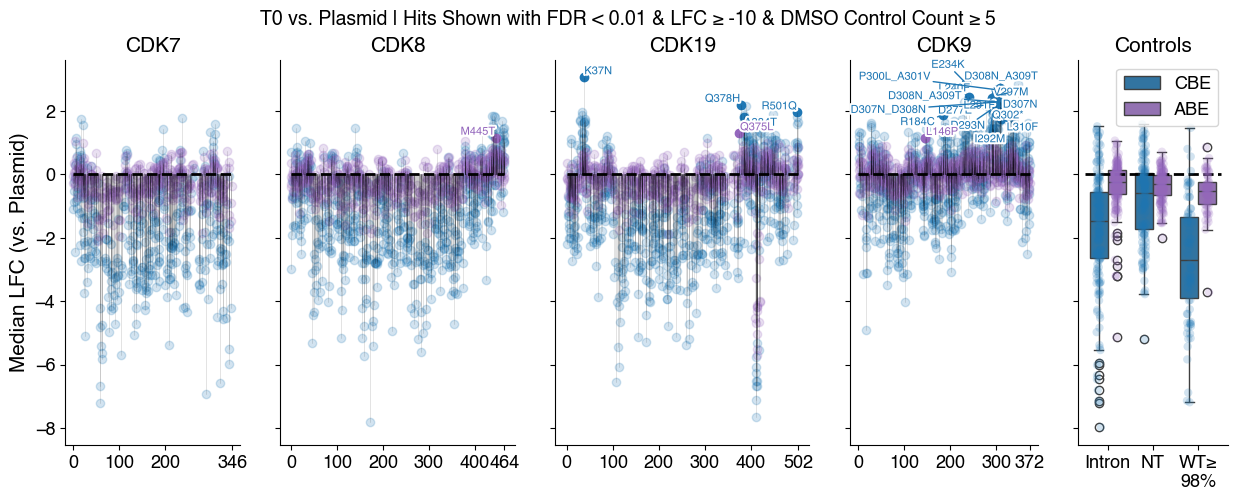

In [ ]:
FDR_cutoff = .01
LFC_cutoff = -10
min_DMSO_counts = 5 #here refers to plasmid counts
WT_cutoff = 98

genes = ['CDK7', 'CDK8', 'CDK19', 'CDK9']

targ_CBE2 = targ_CBE[(targ_CBE['Plasmid_RPM']>=min_DMSO_counts) & (targ_CBE['Gene'].isin(genes)) & (targ_CBE['WT_perc']<WT_cutoff)]
targ_ABE2 = targ_ABE[(targ_ABE['Plasmid_RPM']>=min_DMSO_counts) & (targ_ABE['Gene'].isin(genes)) & (targ_ABE['WT_perc']<WT_cutoff)]

plot_ABE = True
plot_CBE = True

conditions = ['T0', 'DMSO']

true_name = ['T0 vs. Plasmid', 'DMSO vs. Plasmid']

condition_dict = dict(zip(conditions, true_name))

condition_of_interest = 'T0'
name_CBE = f'LFC_median_{condition_of_interest}'
FDR_CBE = f'FDR_high_{condition_of_interest}'

genes = ['CDK7', 'CDK8', 'CDK19', 'CDK9']
ax_dict = {'CDK7':0, 'CDK8':1, 'CDK19':2, 'CDK9':3}

fig, ax = plt.subplots(1,5, figsize=(15,5), sharey=True, width_ratios=[352, 472, 511, 379, 300])

xticks = [[0,100,200,346],
          [0,100,200,300,400,464],
          [0,100,200,300,400,502],
          [0,100,200,300,372]]

#-------plot CBE--------
if plot_CBE == True:
    for i, gene in enumerate(genes):
        s = targ_CBE2[targ_CBE2['Gene']==gene]
        
        x = ax_dict[gene]

        #bb1 = s[(s[name_CBE]<cutoff) | (s[name_CBE]>cutoff_low)]
        #bb2 = s[(s[name_CBE]>=cutoff) | (s[name_CBE]<=cutoff_low)]

        bb1 = s[(s[FDR_CBE]>FDR_cutoff) | ((s[name_CBE]<LFC_cutoff))]
        bb2 = s[(s[FDR_CBE]<=FDR_cutoff) & ((s[name_CBE]>=LFC_cutoff))]

        ax[x].scatter(bb1['Codon_1'], bb1[name_CBE], alpha=.2, color='tab:blue')
        ax[x].scatter(bb2['Codon_1'], bb2[name_CBE], alpha=1, color='tab:blue')

        for iii, val in bb2.iterrows():
            ax[x].plot([val['Codon_1'], val['Codon_1']], [0,val[name_CBE]], linewidth=.4, color='black', alpha=.2)
        for iii, val in bb1.iterrows():
            ax[x].plot([val['Codon_1'], val['Codon_1']], [0,val[name_CBE]], linewidth=.4, color='black', alpha=.2)

        ax[x].spines[['right', 'top']].set_visible(False)
        ax[x].tick_params(axis='both', which='major', labelsize=13)
        ax[x].set_xticks(xticks[i])

        t = list(bb2['Top_HGVSp'])
        x2=list(bb2['Codon_1'])
        y = list(bb2[name_CBE])

        if len(bb2)>0:
            texts = [ax[x].text(x2[i], y[i], t[i], fontsize=8, color='tab:blue', path_effects=[PathEffects.withStroke(linewidth=3,
                                                                                            foreground="w")]) for i in range(len(x2))] #bbox = dict(boxstyle = 'round,pad=0.5', fc = 'white', alpha = .9)

            adjust_text(texts,only_move={'points':'xy', 'texts':'xy'}, ax=ax[x], arrowprops=dict(arrowstyle="-", linewidth=1, alpha=1, color='tab:blue'))

#-----plot ABE-------
if plot_ABE== True:
    for i, gene in enumerate(genes):
        s = targ_ABE2[targ_ABE2['Gene']==gene]
        
        x = ax_dict[gene]

        bb1 = s[(s[FDR_CBE]>FDR_cutoff) | ((s[name_CBE]<LFC_cutoff))]
        bb2 = s[(s[FDR_CBE]<=FDR_cutoff) & ((s[name_CBE]>=LFC_cutoff))]

        ax[x].scatter(bb1['Codon_1'], bb1[name_CBE], alpha=.2, color='tab:purple')
        ax[x].scatter(bb2['Codon_1'], bb2[name_CBE], alpha=1, color='tab:purple')

        for iii, val in bb2.iterrows():
            ax[x].plot([val['Codon_1'], val['Codon_1']], [0,val[name_CBE]], linewidth=.4, color='black', alpha=.2)
        for iii, val in bb1.iterrows():
            ax[x].plot([val['Codon_1'], val['Codon_1']], [0,val[name_CBE]], linewidth=.4, color='black', alpha=.2)


        ax[x].spines[['right', 'top']].set_visible(False)
        ax[x].tick_params(axis='both', which='major', labelsize=13)
        ax[x].set_xticks(xticks[i])

        t = list(bb2['Top_HGVSp'])
        x2=list(bb2['Codon_1'])
        y = list(bb2[name_CBE])

        if len(bb2)>0:
            texts = [ax[x].text(x2[i], y[i], t[i], fontsize=8, color='tab:purple', path_effects=[PathEffects.withStroke(linewidth=3,
                                                                                            foreground="w")]) for i in range(len(x2))] #bbox = dict(boxstyle = 'round,pad=0.5', fc = 'white', alpha = .9)

            adjust_text(texts,only_move={'points':'xy', 'texts':'xy'}, ax=ax[x], arrowprops=dict(arrowstyle="-", linewidth=1, alpha=1, color='tab:purple'))


ax[0].plot([0,346], [0,0], linewidth=2, color='black', linestyle='dashed')
ax[1].plot([0,464], [0,0], linewidth=2, color='black', linestyle='dashed')
ax[2].plot([0,502], [0,0], linewidth=2, color='black', linestyle='dashed')
ax[3].plot([0,372], [0,0], linewidth=2, color='black', linestyle='dashed')

ax[0].set_title('CDK7', fontsize=15)
ax[1].set_title('CDK8', fontsize=15)
ax[2].set_title('CDK19', fontsize=15)
ax[3].set_title('CDK9', fontsize=15)

ax[0].set_ylabel('Median LFC (vs. Plasmid)', fontsize=15)


#-----controls plotting--------
controls_combined = control_maker(targ_ABE, targ_CBE, WT_cutoff)
sns.stripplot(data = controls_combined, x='Guide Class', y=name_CBE,hue='Editor', ax=ax[4], palette=['tab:blue', 'tab:purple'], alpha=.2, dodge=True, s=6, legend=False)
sns.boxplot(data = controls_combined, x='Guide Class', y=name_CBE,hue='Editor', ax=ax[4], palette=['tab:blue', 'tab:purple'])

ax[4].plot([-.5,2.5], [0,0], linewidth=2, color='black', linestyle='dashed')

ax[4].spines[['right', 'top']].set_visible(False)
ax[4].tick_params(axis='both', which='major', labelsize=13)
ax[4].set_xlabel('')
ax[4].set_title('Controls', fontsize=15)
ax[4].legend(fontsize=13)


fig.suptitle(f'{condition_dict[condition_of_interest]} | Hits Shown with FDR < {FDR_cutoff} & LFC ≥ {LFC_cutoff} & DMSO Control Count ≥ {min_DMSO_counts}', fontsize=14)

#fig.savefig(f'figures/{condition_of_interest}_v_plasmid.png', dpi=300)

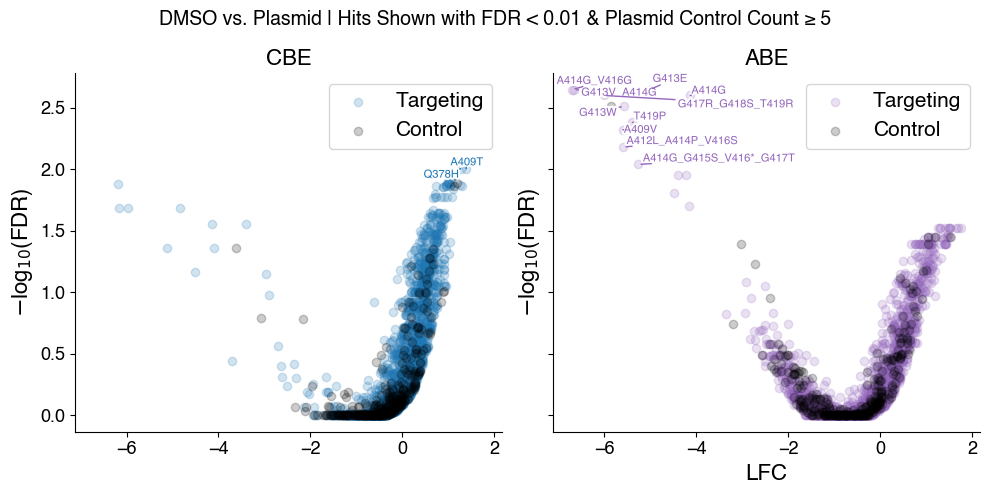

In [272]:
FDR_cutoff = .01
LFC_cutoff = -10
min_DMSO_counts = 5 #here refers to plasmid counts
WT_cutoff = 98

genes = ['CDK7', 'CDK8', 'CDK19', 'CDK9']

targ_CBE2 = targ_CBE[(targ_CBE['Plasmid_RPM']>=min_DMSO_counts) & (targ_CBE['Gene'].isin(genes)) & (targ_CBE['WT_perc']<WT_cutoff)]
targ_ABE2 = targ_ABE[(targ_ABE['Plasmid_RPM']>=min_DMSO_counts) & (targ_ABE['Gene'].isin(genes)) & (targ_ABE['WT_perc']<WT_cutoff)]

controls_combined = control_maker(targ_ABE, targ_CBE, WT_cutoff)


conditions = ['T0', 'DMSO']

true_name = ['T0 vs. Plasmid', 'DMSO vs. Plasmid']

condition_dict = dict(zip(conditions, true_name))

condition_of_interest = 'DMSO'
name = f'LFC_median_{condition_of_interest}'
FDR = f'FDR_{condition_of_interest}'

ax_dict = {'CDK7':0, 'CDK8':1, 'CDK19':2, 'CDK9':3}

fig, ax = plt.subplots(1,2, figsize=(10,5), sharey=True, sharex=True)

ax[0].scatter(targ_CBE2[name], -np.log10(targ_CBE2[FDR]),alpha=.2, color='tab:blue', label='Targeting')
ax[1].scatter(targ_ABE2[name], -np.log10(targ_ABE2[FDR]),alpha=.2, color='tab:purple', label='Targeting')


controls_ABE = controls_combined[controls_combined['Editor']=='ABE']
controls_CBE = controls_combined[controls_combined['Editor']=='CBE']

ax[1].scatter(controls_ABE[name], -np.log10(controls_ABE[FDR]), color='black',alpha=.2, label='Control')
ax[0].scatter(controls_CBE[name], -np.log10(controls_CBE[FDR]), color='black',alpha=.2, label='Control')
ax[0].legend(fontsize=15)
ax[1].legend(fontsize=15)

ax[0].spines[['right', 'top']].set_visible(False)
ax[0].tick_params(axis='both', which='major', labelsize=13)
ax[1].spines[['right', 'top']].set_visible(False)
ax[1].tick_params(axis='both', which='major', labelsize=13)

ax[0].set_ylabel('$-$log$_{10}$(FDR)', fontsize=16)
ax[1].set_ylabel('$-$log$_{10}$(FDR)', fontsize=16)
ax[1].set_xlabel('LFC', fontsize=16)


ax[0].set_title('CBE', fontsize=16)
ax[1].set_title('ABE', fontsize=16)



#----and add labeling-----------------------------

bb2 = targ_CBE2[targ_CBE2[FDR]<=FDR_cutoff]

t = list(bb2['Top_HGVSp'])
x2=list(bb2[name])
y = list(-np.log10(bb2[FDR]))

if len(bb2)>0:
    texts = [ax[0].text(x2[i], y[i], t[i], fontsize=8, color='tab:blue', path_effects=[PathEffects.withStroke(linewidth=3,
                                                                                    foreground="w")]) for i in range(len(x2))] #bbox = dict(boxstyle = 'round,pad=0.5', fc = 'white', alpha = .9)

    adjust_text(texts,only_move={'points':'xy', 'texts':'xy'}, ax=ax[0], arrowprops=dict(arrowstyle="-", linewidth=1, alpha=1, color='tab:blue'))

bb2 = targ_ABE2[targ_ABE2[FDR]<=FDR_cutoff]

t = list(bb2['Top_HGVSp'])
x2=list(bb2[name])
y = list(-np.log10(bb2[FDR]))

if len(bb2)>0:
    texts = [ax[1].text(x2[i], y[i], t[i], fontsize=8, color='tab:purple', path_effects=[PathEffects.withStroke(linewidth=3,
                                                                                    foreground="w")]) for i in range(len(x2))] #bbox = dict(boxstyle = 'round,pad=0.5', fc = 'white', alpha = .9)

    adjust_text(texts,only_move={'points':'xy', 'texts':'xy'}, ax=ax[1], arrowprops=dict(arrowstyle="-", linewidth=1, alpha=1, color='tab:purple'))



#-------title and save------------------
fig.suptitle(f'{condition_dict[condition_of_interest]} | Hits Shown with FDR < {FDR_cutoff} & Plasmid Control Count ≥ {min_DMSO_counts}', fontsize=14)

fig.tight_layout()

fig.savefig(f'figures/{condition_of_interest}_volcano.png', dpi=300)

In [306]:
library = pd.read_csv('CDK_library_final.csv')
print(list(library[library['gRNA_id'].isin(list(targ_ABE2.sort_values(by=name)[:20]['gRNA_id']))]['proto_G+19']))

['GTGGTTGGTGTTCTTATCTC', 'GCAGTGCCTTTTAAAAGAAA', 'GTTTCTTGGGCAATCCTCCT', 'GAGCTGACATGGGCTTTGCC', 'GTGCCCCCGACCCCGGCCCC', 'GCCCCGGCCCCAGCCCCACC', 'GCGGCCCCAGCCCCACCTGC', 'GAACCTATTGCCCATATATC', 'GCCGGGGTCGGGGGCACCGG', 'GGGCCGGGGTCGGGGGCACC', 'GGGGCCGGGGTCGGGGGCAC', 'GGGCTGGGGCCGGGGTCGGG', 'GGGGCTGGGGCCGGGGTCGG', 'GGGGGCTGGGGCCGGGGTCG', 'GTGGGGCTGGGGCCGGGGTC', 'GGTGGGGCTGGGGCCGGGGT', 'GCAGGTGGGGCTGGGGCCGG', 'GGCAGGTGGGGCTGGGGCCG', 'GCGCAGGTGGGGCTGGGGCC', 'GCCGCAGGTGGGGCTGGGGC']


# Processing KB-0742 compound mutant data

- Working from the matched guide counts due to potential sequencing issues

In [212]:
fp = 'KB_compound_mut_screen_data/counts'
k = os.listdir(fp)
k = sorted(k)

df = pd.read_csv('CDK_library_final.csv')
pool1 = list(df[df['Pool']=='F1-R1']['gRNA_id'])
pool2 = list(df[df['Pool']=='F2-R2']['gRNA_id'])
pool3 = list(df[df['Pool']=='F3-R3']['gRNA_id'])


name_dict = { 'D25-173001' : 'T0_REP1',
    'D25-173002' : 'T0_REP2',
    'D25-173003' : 'T0_REP3',
    'D25-173004' : 'DMSO_REP1',
    'D25-173005' : 'DMSO_REP2',
    'D25-173006' : 'DMSO_REP3',
    'D25-173007' : 'KB_2000_REP1',
    'D25-173008' : 'KB_2000_REP2',
    'D25-173009' : 'KB_2000_REP3',
    'D25-173010' : 'KB_4000_REP1',
    'D25-173011' : 'KB_4000_REP2',
    'D25-173012' : 'KB_4000_REP3'}


new_name = []
df_holder = []
for i, val in enumerate(k):
    n = name_dict[val[:10]] + '_' + val[11]
    new_name.append(n)
    a = pd.read_csv(f'{fp}/{val}')

    a_pool1 = a[a['Guide_ID'].isin(pool1)]
    a_pool2 = a[a['Guide_ID'].isin(pool2)]
    a_pool3 = a[a['Guide_ID'].isin(pool3)]

    df_holder.append(a_pool1)
    print(f'{n}: pool1: {sum(a_pool1["bc_count"])}, pool2:{sum(a_pool2["bc_count"])}, pool3: {sum(a_pool3["bc_count"])}')
    print(f'MGC {n}: pool1: {sum(a_pool1["matched_guide_count"])}, pool2:{sum(a_pool2["matched_guide_count"])}, pool3: {sum(a_pool3["matched_guide_count"])}')


count_dict = dict(zip(new_name, df_holder))

T0_REP1_1: pool1: 12105659.0, pool2:22725.0, pool3: 9777.0
MGC T0_REP1_1: pool1: 6039955.0, pool2:8234.0, pool3: 2545.0
T0_REP1_2: pool1: 12125477.0, pool2:23201.0, pool3: 9800.0
MGC T0_REP1_2: pool1: 6045239.0, pool2:8530.0, pool3: 2459.0
T0_REP2_1: pool1: 17576153.0, pool2:17716.0, pool3: 20486.0
MGC T0_REP2_1: pool1: 8860644.0, pool2:5417.0, pool3: 11746.0
T0_REP2_2: pool1: 17623447.0, pool2:17685.0, pool3: 20442.0
MGC T0_REP2_2: pool1: 8882842.0, pool2:5430.0, pool3: 11696.0
T0_REP3_1: pool1: 30622477.0, pool2:13228.0, pool3: 16132.0
MGC T0_REP3_1: pool1: 15561905.0, pool2:6773.0, pool3: 5181.0
T0_REP3_2: pool1: 30686450.0, pool2:13032.0, pool3: 16173.0
MGC T0_REP3_2: pool1: 15581708.0, pool2:6619.0, pool3: 5098.0
DMSO_REP1_1: pool1: 15339056.0, pool2:11492.0, pool3: 25049.0
MGC DMSO_REP1_1: pool1: 7611845.0, pool2:3161.0, pool3: 8037.0
DMSO_REP1_2: pool1: 15380408.0, pool2:11468.0, pool3: 25089.0
MGC DMSO_REP1_2: pool1: 7624993.0, pool2:3181.0, pool3: 7833.0
DMSO_REP2_1: pool1: 24

In [213]:
bc_counts_combined = []
proto_counts_combined = []
for i in name_dict.values():
    flow1 = count_dict[i+'_1']
    flow2 = count_dict[i+'_2']

    c = np.asarray(flow1['bc_count']) + np.asarray(flow2['bc_count'])

    #pp = np.asarray(flow1['total_guide_count']) + np.asarray(flow2['total_guide_count'])
    pp = np.asarray(flow1['matched_guide_count']) + np.asarray(flow2['matched_guide_count'])

    bc_counts_combined.append(c)
    proto_counts_combined.append(pp)

    assert list(flow1['Guide_ID']) == list(count_dict[new_name[0]]['Guide_ID'])

count_df  = pd.DataFrame(dict(zip(name_dict.values(), bc_counts_combined)))
count_df_w_gRNA_name = count_df.copy()
count_df_w_gRNA_name['gRNA_id'] = list(count_dict[new_name[0]]['Guide_ID'])


count_df_protos = pd.DataFrame(dict(zip(name_dict.values(), proto_counts_combined)))
count_df_protos_w_gRNA_name = count_df_protos.copy()
count_df_protos_w_gRNA_name['gRNA_id'] = list(count_dict[new_name[0]]['Guide_ID'])


gene_name = []
for i, val in count_df_w_gRNA_name.iterrows():
    gid = val['gRNA_id']
    subset = df[df['gRNA_id']==gid]

    if subset['classification'].values[0]=='intron':
        gene_name.append(subset['Gene'].values[0] + '_intron')
    elif subset['classification'].values[0]=='non-targeting control':
        gene_name.append('NT')
    elif subset['classification'].values[0]=='targeting':
        gene_name.append(subset['Gene'].values[0])

count_df_w_gRNA_name['gene'] = gene_name
count_df_protos_w_gRNA_name['gene'] = gene_name

In [227]:
#add plasmid counts!

CBE_counts = pd.read_csv('MAGeCK/CDK_bc_counts.txt', sep='\t').rename(columns={'sgRNA':'gRNA_id'})

assert list(count_df_protos_w_gRNA_name['gRNA_id']) == list(CBE_counts['gRNA_id'])

count_df_protos_w_gRNA_name['Plasmid'] = CBE_counts['Plasmid']
compound_counts = count_df_protos_w_gRNA_name[['gRNA_id', 'gene', 'Plasmid', 'T0_REP1', 'T0_REP2','T0_REP3','DMSO_REP1', 'DMSO_REP2', 'DMSO_REP3']]
compound_counts

,gRNA_id,gene,Plasmid,T0_REP1,T0_REP2,T0_REP3,DMSO_REP1,DMSO_REP2,DMSO_REP3
0,gRNA_CDK7_targ_1,CDK7,24204.0,7691.0,7000.0,15782.0,13356.0,11317.0,10179.0
1,gRNA_CDK7_targ_2,CDK7,20910.0,5008.0,4078.0,13306.0,4532.0,9406.0,5140.0
2,gRNA_CDK7_targ_3,CDK7,8754.0,5452.0,2110.0,5502.0,3866.0,3300.0,1726.0
3,gRNA_CDK7_targ_4,CDK7,17303.0,5071.0,8370.0,22966.0,15855.0,14127.0,8897.0
4,gRNA_CDK7_targ_5,CDK7,5302.0,3898.0,5895.0,10954.0,2191.0,11529.0,5034.0
...,...,...,...,...,...,...,...,...,...
2725,gRNA_nt_8935,NT,19123.0,2072.0,4904.0,9525.0,1756.0,5514.0,3458.0
2726,gRNA_nt_8936,NT,8528.0,1105.0,2819.0,8991.0,5064.0,4546.0,4864.0
2727,gRNA_nt_8937,NT,16515.0,15099.0,9348.0,15690.0,3127.0,4317.0,7795.0
2728,gRNA_nt_8938,NT,9383.0,5575.0,1509.0,2907.0,3381.0,1750.0,1677.0


In [228]:
samples = list(compound_counts.columns[2:])

compound_RPM = compound_counts.copy()

#add pseudocount of 1 to each sample
#and normalize + calculate RPM
pseudocount = 1
for k in samples:
    col = np.asarray(compound_counts[k]) + pseudocount
    sum_col = np.sum(col)
    rpm = 1e6*(col/sum_col)
    compound_RPM[k] = rpm

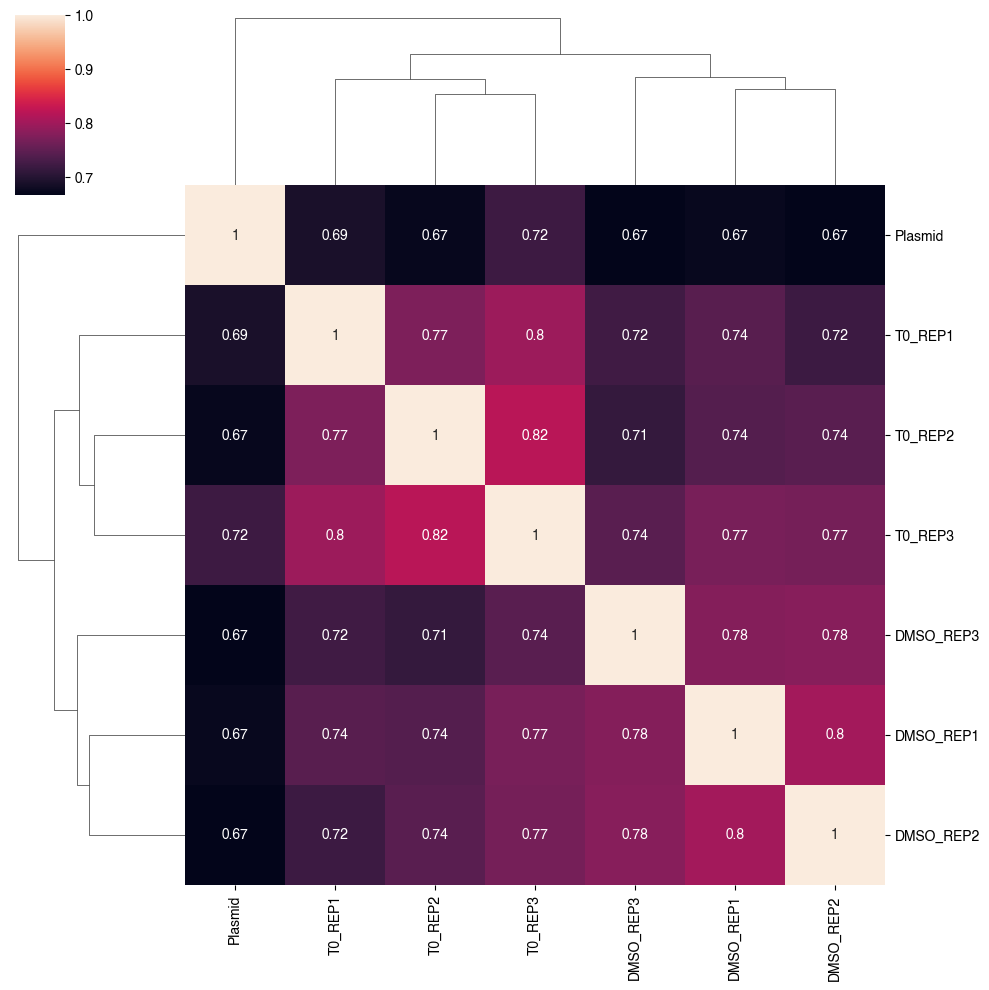

In [234]:
sns.clustermap(compound_RPM[compound_counts.columns[2:]].corr(method='spearman'), annot=True)

In [235]:
plasmid_median = np.asarray(compound_RPM['Plasmid'])

conditions = ['T0', 'DMSO']

df_holder2 = []
for condition_of_interest in conditions:

#condition_of_interest = 'KI-CDK9d-32_1000nM'
    samp_of_interest = [f'{condition_of_interest}_REP{i}' for i in range(1,4)]

    #calculate log2fc
    lfc_list = []
    for k in samp_of_interest:
        col = compound_RPM[k]
        lfc = np.log2(col/plasmid_median)

        lfc_list.append(lfc)

    lfc_table = pd.DataFrame(dict(zip(samp_of_interest, lfc_list)))
    lfc_table[f'LFC_avg_{condition_of_interest}'] = np.average(lfc_table[samp_of_interest], axis=1)
    lfc_table[f'LFC_median_{condition_of_interest}'] = np.median(lfc_table[samp_of_interest], axis=1)
    lfc_table['Plasmid_RPM'] = plasmid_median
    ids = compound_RPM[['gRNA_id', 'gene']]

    LFC_df = pd.concat((ids, lfc_table), axis=1)
    LFC_df = one_sided_FDR(condition_of_interest, LFC_df)
    df_holder2.append(LFC_df)

873
873


In [236]:
combined_LFC = pd.concat(df_holder2, axis=1)
combined_LFC = combined_LFC.loc[:,~combined_LFC.columns.duplicated()].copy()
combined_LFC = combined_LFC.rename(columns = {'gene':'Gene'})


CBE = pd.read_csv('CBE_master_Z_table.csv')
edit_info = CBE[['gRNA_id', 'WT_perc', 'Top_HGVSp', 'Top_HGVSp_%', 'Codon_1']]
targ_compound = pd.merge(combined_LFC, edit_info, on='gRNA_id')

In [237]:
targ_compound

,gRNA_id,Gene,T0_REP1,T0_REP2,T0_REP3,LFC_avg_T0,LFC_median_T0,Plasmid_RPM,p_high_unadjusted_T0,p_low_unadjusted_T0,...,p_high_unadjusted_DMSO,p_low_unadjusted_DMSO,FDR_high_DMSO,FDR_low_DMSO,p_unadjusted_DMSO,FDR_DMSO,WT_perc,Top_HGVSp,Top_HGVSp_%,Codon_1
0,gRNA_CDK7_targ_1,CDK7,-0.021150,-0.710892,-0.349705,-0.360583,-0.349705,645.734931,0.607092,0.660714,...,0.211393,0.913887,0.726831,1.0,0.211393,0.726831,26.380917,A2V,55.961404,2.0
1,gRNA_CDK7_targ_2,CDK7,-0.428943,-1.279195,-0.384848,-0.697662,-0.428943,557.858423,0.779732,0.442978,...,0.679748,0.619792,0.999996,1.0,0.619792,0.999996,19.888296,A2V,46.477928,2.0
2,gRNA_CDK7_targ_3,CDK7,0.949668,-0.973401,-0.402661,-0.142131,-0.402661,233.563698,0.232541,0.680284,...,0.553580,0.692887,0.999996,1.0,0.553580,0.999996,28.020919,A2V,22.804246,2.0
3,gRNA_CDK7_targ_4,CDK7,-0.137754,0.031146,0.675685,0.189692,0.031146,461.631780,0.182141,0.923569,...,0.021323,0.993996,0.218843,1.0,0.021323,0.218843,33.897470,S7F,42.264560,7.0
4,gRNA_CDK7_targ_5,CDK7,1.189020,1.231707,1.313937,1.244888,1.231707,141.472107,0.000947,0.999952,...,0.002925,0.992554,0.088603,1.0,0.002925,0.088603,12.159279,S7F,52.566937,7.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2725,gRNA_nt_8935,NT,-1.572868,-0.884280,-0.738214,-1.065120,-0.884280,510.185285,0.917204,0.247956,...,0.888122,0.306842,0.999996,1.0,0.306842,0.999996,0.000000,0,0.000000,0.0
2726,gRNA_nt_8936,NT,-1.314301,-0.517902,0.343494,-0.496236,-0.517902,227.534527,0.541786,0.527323,...,0.093419,0.958682,0.474923,1.0,0.093419,0.474923,0.000000,0,0.000000,0.0
2727,gRNA_nt_8937,NT,1.503409,0.257799,0.193301,0.651503,0.257799,440.609714,0.019872,0.983752,...,0.482035,0.579880,0.999996,1.0,0.482035,0.999996,0.000000,0,0.000000,0.0
2728,gRNA_nt_8938,NT,0.881752,-1.556875,-1.422947,-0.699357,-1.422947,250.344003,0.388798,0.322184,...,0.741064,0.470539,0.999996,1.0,0.470539,0.999996,0.000000,0,0.000000,0.0


Text(0.5, 0.98, 'DMSO vs. Plasmid | Hits Shown with FDR < 0.01 & LFC ≥\xa0-10 & DMSO Control Count ≥ 5')

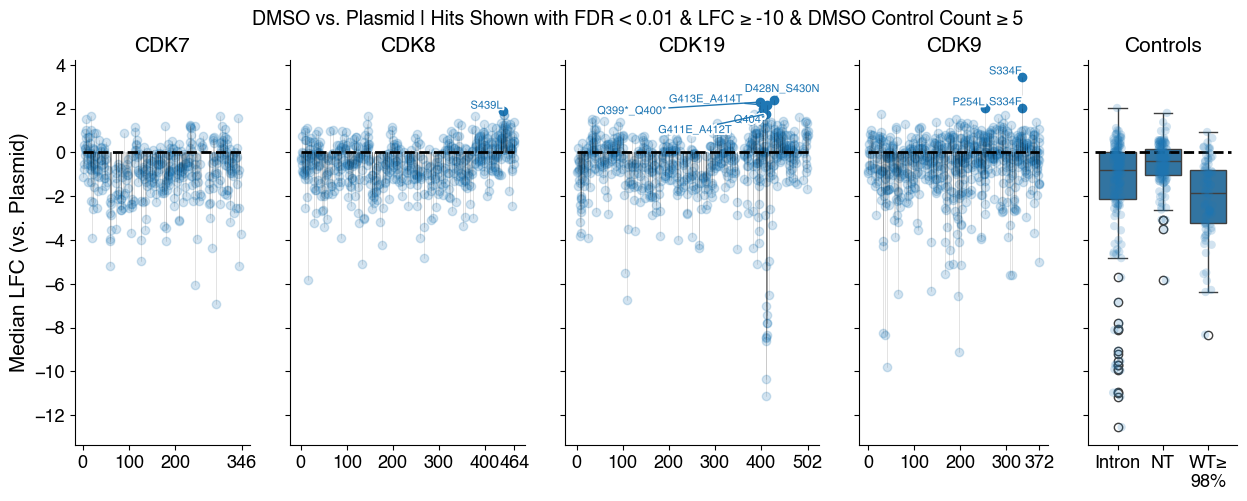

In [490]:
FDR_cutoff = .01
LFC_cutoff = -10
min_DMSO_counts = 5 #here refers to plasmid counts
WT_cutoff = 98

genes = ['CDK7', 'CDK8', 'CDK19', 'CDK9']

#targ_CBE2 = targ_CBE[(targ_CBE['Plasmid_RPM']>=min_DMSO_counts) & (targ_CBE['Gene'].isin(genes)) & (targ_CBE['WT_perc']<WT_cutoff)]
targ_CBE2 = targ_compound[(targ_compound['Plasmid_RPM']>=min_DMSO_counts) & (targ_compound['Gene'].isin(genes)) & (targ_compound['WT_perc']<WT_cutoff)]
#targ_ABE2 = targ_ABE[(targ_ABE['Plasmid_RPM']>=min_DMSO_counts) & (targ_ABE['Gene'].isin(genes)) & (targ_ABE['WT_perc']<WT_cutoff)]

plot_ABE = False
plot_CBE = True

conditions = ['T0', 'DMSO']

true_name = ['T0 vs. Plasmid', 'DMSO vs. Plasmid']

condition_dict = dict(zip(conditions, true_name))

condition_of_interest = 'DMSO'
name_CBE = f'LFC_median_{condition_of_interest}'
FDR_CBE = f'FDR_high_{condition_of_interest}'

genes = ['CDK7', 'CDK8', 'CDK19', 'CDK9']
ax_dict = {'CDK7':0, 'CDK8':1, 'CDK19':2, 'CDK9':3}

fig, ax = plt.subplots(1,5, figsize=(15,5), sharey=True, width_ratios=[352, 472, 511, 379, 300])

xticks = [[0,100,200,346],
          [0,100,200,300,400,464],
          [0,100,200,300,400,502],
          [0,100,200,300,372]]

#-------plot CBE--------
if plot_CBE == True:
    for i, gene in enumerate(genes):
        s = targ_CBE2[targ_CBE2['Gene']==gene]
        
        x = ax_dict[gene]

        #bb1 = s[(s[name_CBE]<cutoff) | (s[name_CBE]>cutoff_low)]
        #bb2 = s[(s[name_CBE]>=cutoff) | (s[name_CBE]<=cutoff_low)]

        bb1 = s[(s[FDR_CBE]>FDR_cutoff) | ((s[name_CBE]<LFC_cutoff))]
        bb2 = s[(s[FDR_CBE]<=FDR_cutoff) & ((s[name_CBE]>=LFC_cutoff))]

        ax[x].scatter(bb1['Codon_1'], bb1[name_CBE], alpha=.2, color='tab:blue')
        ax[x].scatter(bb2['Codon_1'], bb2[name_CBE], alpha=1, color='tab:blue')

        for iii, val in bb2.iterrows():
            ax[x].plot([val['Codon_1'], val['Codon_1']], [0,val[name_CBE]], linewidth=.4, color='black', alpha=.2)
        for iii, val in bb1.iterrows():
            ax[x].plot([val['Codon_1'], val['Codon_1']], [0,val[name_CBE]], linewidth=.4, color='black', alpha=.2)

        ax[x].spines[['right', 'top']].set_visible(False)
        ax[x].tick_params(axis='both', which='major', labelsize=13)
        ax[x].set_xticks(xticks[i])

        t = list(bb2['Top_HGVSp'])
        x2=list(bb2['Codon_1'])
        y = list(bb2[name_CBE])

        if len(bb2)>0:
            texts = [ax[x].text(x2[i], y[i], t[i], fontsize=8, color='tab:blue', path_effects=[PathEffects.withStroke(linewidth=3,
                                                                                            foreground="w")]) for i in range(len(x2))] #bbox = dict(boxstyle = 'round,pad=0.5', fc = 'white', alpha = .9)

            adjust_text(texts,only_move={'points':'xy', 'texts':'xy'}, ax=ax[x], arrowprops=dict(arrowstyle="-", linewidth=1, alpha=1, color='tab:blue'))

#-----plot ABE-------
if plot_ABE== True:
    for i, gene in enumerate(genes):
        s = targ_ABE2[targ_ABE2['Gene']==gene]
        
        x = ax_dict[gene]

        bb1 = s[(s[FDR_CBE]>FDR_cutoff) | ((s[name_CBE]<LFC_cutoff))]
        bb2 = s[(s[FDR_CBE]<=FDR_cutoff) & ((s[name_CBE]>=LFC_cutoff))]

        ax[x].scatter(bb1['Codon_1'], bb1[name_CBE], alpha=.2, color='tab:purple')
        ax[x].scatter(bb2['Codon_1'], bb2[name_CBE], alpha=1, color='tab:purple')

        for iii, val in bb2.iterrows():
            ax[x].plot([val['Codon_1'], val['Codon_1']], [0,val[name_CBE]], linewidth=.4, color='black', alpha=.2)
        for iii, val in bb1.iterrows():
            ax[x].plot([val['Codon_1'], val['Codon_1']], [0,val[name_CBE]], linewidth=.4, color='black', alpha=.2)


        ax[x].spines[['right', 'top']].set_visible(False)
        ax[x].tick_params(axis='both', which='major', labelsize=13)
        ax[x].set_xticks(xticks[i])

        t = list(bb2['Top_HGVSp'])
        x2=list(bb2['Codon_1'])
        y = list(bb2[name_CBE])

        if len(bb2)>0:
            texts = [ax[x].text(x2[i], y[i], t[i], fontsize=8, color='tab:purple', path_effects=[PathEffects.withStroke(linewidth=3,
                                                                                            foreground="w")]) for i in range(len(x2))] #bbox = dict(boxstyle = 'round,pad=0.5', fc = 'white', alpha = .9)

            adjust_text(texts,only_move={'points':'xy', 'texts':'xy'}, ax=ax[x], arrowprops=dict(arrowstyle="-", linewidth=1, alpha=1, color='tab:purple'))


ax[0].plot([0,346], [0,0], linewidth=2, color='black', linestyle='dashed')
ax[1].plot([0,464], [0,0], linewidth=2, color='black', linestyle='dashed')
ax[2].plot([0,502], [0,0], linewidth=2, color='black', linestyle='dashed')
ax[3].plot([0,372], [0,0], linewidth=2, color='black', linestyle='dashed')

ax[0].set_title('CDK7', fontsize=15)
ax[1].set_title('CDK8', fontsize=15)
ax[2].set_title('CDK19', fontsize=15)
ax[3].set_title('CDK9', fontsize=15)

ax[0].set_ylabel('Median LFC (vs. Plasmid)', fontsize=15)


#-----controls plotting--------
controls_combined = control_maker(targ_compound[targ_compound['gRNA_id']=='poop'], targ_compound, WT_cutoff)
sns.stripplot(data = controls_combined, x='Guide Class', y=name_CBE,hue='Editor', ax=ax[4], palette=['tab:blue', 'tab:purple'], alpha=.2, dodge=True, s=6, legend=False)
sns.boxplot(data = controls_combined, x='Guide Class', y=name_CBE,hue='Editor', ax=ax[4], palette=['tab:blue', 'tab:purple'], legend=False)

ax[4].plot([-.5,2.5], [0,0], linewidth=2, color='black', linestyle='dashed')

ax[4].spines[['right', 'top']].set_visible(False)
ax[4].tick_params(axis='both', which='major', labelsize=13)
ax[4].set_xlabel('')
ax[4].set_title('Controls', fontsize=15)
#ax[4].legend(fontsize=13)


fig.suptitle(f'{condition_dict[condition_of_interest]} | Hits Shown with FDR < {FDR_cutoff} & LFC ≥ {LFC_cutoff} & DMSO Control Count ≥ {min_DMSO_counts}', fontsize=14)

In [491]:
targ_compound[targ_compound['Top_HGVSp']=='C106Y_E107K']

,gRNA_id,Gene,T0_REP1,T0_REP2,T0_REP3,LFC_avg_T0,LFC_median_T0,Plasmid_RPM,p_high_unadjusted_T0,p_low_unadjusted_T0,...,FDR_high_DMSO,FDR_low_DMSO,p_unadjusted_DMSO,FDR_DMSO,WT_perc,Top_HGVSp,Top_HGVSp_%,Codon_1,delta_T0,delta_DMSO
1474,gRNA_CDK9_targ_1475,CDK9,-1.5379,0.973962,0.902833,0.112965,0.902833,110.01904,0.054266,0.713591,...,0.999996,1.0,0.06096,0.999996,1.004245,C106Y_E107K,62.116532,106.0,4.033409,-2.143309


In [249]:
targ_compound['delta_T0'] = targ_compound['LFC_median_T0'] - targ_CBE['LFC_median_T0']
targ_compound['delta_DMSO'] = targ_compound['LFC_median_DMSO'] - targ_CBE['LFC_median_DMSO']

assert list(targ_compound['gRNA_id']) == list(targ_CBE['gRNA_id'])

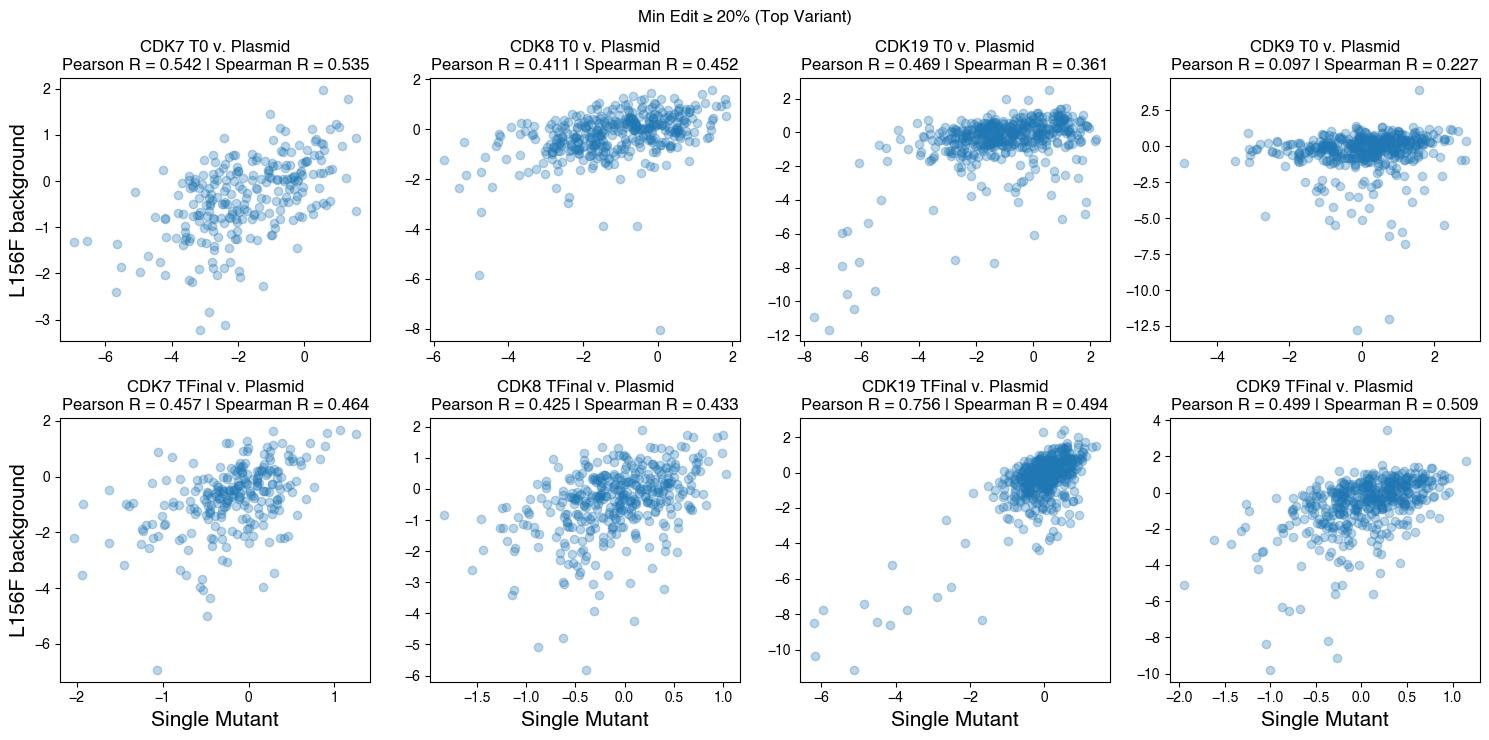

In [339]:
g = 'CDK9'
condit = 'DMSO'
edit_cutoff = 20

fig, ax = plt.subplots(2,4,figsize=(15,7.5)) #,sharex=True, sharey=True)

for i, g in enumerate(['CDK7', 'CDK8', 'CDK19', 'CDK9']):
    x,y = targ_CBE[(targ_CBE['Gene']==g) & (targ_CBE['Top_HGVSp_%']>=edit_cutoff)][f'LFC_median_T0'], targ_compound[(targ_compound['Gene']==g) & (targ_compound['Top_HGVSp_%']>=edit_cutoff)][f'LFC_median_T0']
    x2,y2 = targ_CBE[(targ_CBE['Gene']==g) & (targ_CBE['Top_HGVSp_%']>=edit_cutoff)][f'LFC_median_DMSO'], targ_compound[(targ_compound['Gene']==g) & (targ_compound['Top_HGVSp_%']>=edit_cutoff)][f'LFC_median_DMSO']


    ax[0][i].scatter(x,y, alpha=0.3)
    ax[1][i].scatter(x2,y2, alpha=0.3)

    pear = np.round(scipy.stats.pearsonr(x,y).statistic,3)
    spear = np.round(scipy.stats.spearmanr(x,y).statistic,3)
    pear2 = np.round(scipy.stats.pearsonr(x2,y2).statistic,3)
    spear2 = np.round(scipy.stats.spearmanr(x2,y2).statistic,3)

    ax[0][i].set_title(f'{g} T0 v. Plasmid\nPearson R = {pear} | Spearman R = {spear}')
    ax[1][i].set_title(f'{g} TFinal v. Plasmid\nPearson R = {pear2} | Spearman R = {spear2}')

    ax[0][0].set_ylabel('L156F background', fontsize=15)
    ax[1][0].set_ylabel('L156F background', fontsize=15)
    ax[1][0].set_xlabel('Single Mutant', fontsize=15)
    ax[1][1].set_xlabel('Single Mutant', fontsize=15)
    ax[1][2].set_xlabel('Single Mutant', fontsize=15)
    ax[1][3].set_xlabel('Single Mutant', fontsize=15)

fig.suptitle(f'Min Edit ≥ {edit_cutoff}% (Top Variant)')
fig.tight_layout()

In [ ]:
targ_compound[(targ_compound['Gene']=='CDK9') & (targ_compound['Top_HGVSp_%']>=edit_cutoff)].sort_values(by='LFC_median_DMSO')

G42S, E198K, A36T, E32K

,gRNA_id,Gene,T0_REP1,T0_REP2,T0_REP3,LFC_avg_T0,LFC_median_T0,Plasmid_RPM,p_high_unadjusted_T0,p_low_unadjusted_T0,...,FDR_high_DMSO,FDR_low_DMSO,p_unadjusted_DMSO,FDR_DMSO,WT_perc,Top_HGVSp,Top_HGVSp_%,Codon_1,delta_T0,delta_DMSO
1418,gRNA_CDK9_targ_1419,CDK9,-12.036160,-12.590105,-6.646769,-10.424345,-12.036160,347.451012,9.999991e-01,4.133781e-06,...,0.999996,0.205661,0.000678,0.205661,26.473010,G42S,42.502646,42.0,-12.779176,-8.783695
1550,gRNA_CDK9_targ_1551,CDK9,-12.378328,-12.932273,-12.743824,-12.684808,-12.743824,440.449647,1.000000e+00,3.411408e-07,...,0.999996,0.424835,0.002764,0.424835,44.350417,E198K,43.206198,198.0,-12.619820,-8.856043
1416,gRNA_CDK9_targ_1417,CDK9,-2.779531,-2.739445,-1.824229,-2.447735,-2.739445,870.788427,9.964392e-01,2.522906e-02,...,0.999996,0.424835,0.002529,0.424835,28.890271,A36T,43.938791,36.0,-2.136880,-7.305185
1409,gRNA_CDK9_targ_1410,CDK9,-1.957827,-3.688916,-3.147688,-2.931477,-3.147688,531.234029,9.979855e-01,1.489350e-02,...,0.999996,0.777621,0.014454,0.777621,14.606810,E32K,78.165516,32.0,-2.092933,-7.866930
1547,gRNA_CDK9_targ_1548,CDK9,0.004442,-1.313493,-1.248021,-0.852357,-1.248021,431.085757,7.847754e-01,3.338617e-01,...,0.999996,0.581157,0.007238,0.581157,12.538198,R195Q,33.498350,195.0,-0.375618,-5.774193
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1378,gRNA_CDK9_targ_1379,CDK9,1.123328,-1.456894,1.149860,0.272098,1.123328,812.124055,2.202426e-02,7.436389e-01,...,0.047586,1.000000,0.000750,0.047586,9.321679,Q365*,48.983272,365.0,0.286907,0.770789
1193,gRNA_CDK9_targ_1194,CDK9,1.332739,1.299951,0.763894,1.132195,1.299951,459.550916,1.933089e-03,9.997572e-01,...,0.049440,1.000000,0.000909,0.049440,69.528814,H147Y,24.220624,147.0,-0.114653,0.820604
1231,gRNA_CDK9_targ_1232,CDK9,0.259440,0.543380,0.140288,0.314369,0.259440,662.915402,1.313823e-01,9.673645e-01,...,0.040340,1.000000,0.000576,0.040340,20.039810,L192F,43.973047,192.0,-0.389507,1.287552
1645,gRNA_CDK9_targ_1646,CDK9,1.711126,1.085624,1.111415,1.302722,1.111415,701.251328,3.904304e-04,9.999587e-01,...,0.022447,1.000000,0.000183,0.022447,58.800603,V297M,20.626978,297.0,-1.364971,0.580376


In [316]:
ll = list(targ_compound[(targ_compound['Gene']=='CDK9')].sort_values(by='LFC_median_T0')[:20]['gRNA_id'])

In [319]:
targ_compound[(targ_compound['Gene']=='CDK9') & (targ_compound['FDR_T0']<0.1)]

,gRNA_id,Gene,T0_REP1,T0_REP2,T0_REP3,LFC_avg_T0,LFC_median_T0,Plasmid_RPM,p_high_unadjusted_T0,p_low_unadjusted_T0,...,FDR_high_DMSO,FDR_low_DMSO,p_unadjusted_DMSO,FDR_DMSO,WT_perc,Top_HGVSp,Top_HGVSp_%,Codon_1,delta_T0,delta_DMSO
1068,gRNA_CDK9_targ_1069,CDK9,1.377054,1.274867,1.097451,1.249791,1.274867,441.063235,9.267606e-04,9.999495e-01,...,0.275863,1.000000,0.033146,0.275863,48.908722,A23V,22.592361,23.0,1.437849,0.530537
1069,gRNA_CDK9_targ_1070,CDK9,0.424348,2.230517,0.415052,1.023306,0.424348,296.950032,1.888837e-03,9.948719e-01,...,0.193391,1.000000,0.016293,0.193391,55.449244,A23V,35.629335,23.0,0.117699,0.009019
1119,gRNA_CDK9_targ_1120,CDK9,1.491171,0.503207,1.423105,1.139161,1.423105,418.760637,1.294304e-03,9.992822e-01,...,0.054364,1.000000,0.001341,0.054364,29.427924,P60L,37.200071,60.0,1.571856,1.235413
1141,gRNA_CDK9_targ_1142,CDK9,1.068541,0.652349,1.792465,1.171119,1.068541,290.547372,6.403219e-04,9.995786e-01,...,0.379905,1.000000,0.059634,0.379905,13.596024,P91L,63.361886,91.0,1.152177,-0.185665
1193,gRNA_CDK9_targ_1194,CDK9,1.332739,1.299951,0.763894,1.132195,1.299951,459.550916,1.933089e-03,9.997572e-01,...,0.049440,1.000000,0.000909,0.049440,69.528814,H147Y,24.220624,147.0,-0.114653,0.820604
1214,gRNA_CDK9_targ_1215,CDK9,-8.975684,-4.231949,-5.499878,-6.235837,-5.499878,249.890481,9.999491e-01,6.332722e-04,...,0.999996,0.777621,0.013761,0.777621,74.699939,D167E,12.171967,167.0,-3.302332,-5.166245
1220,gRNA_CDK9_targ_1221,CDK9,1.127491,1.099076,0.972042,1.066203,1.099076,721.179607,2.385380e-03,9.998393e-01,...,0.104640,1.000000,0.004945,0.104640,70.560749,A177V,10.412874,177.0,1.101682,0.277256
1224,gRNA_CDK9_targ_1225,CDK9,1.268170,1.413539,1.323260,1.334990,1.323260,471.209092,4.780934e-04,9.999775e-01,...,0.276379,1.000000,0.033911,0.276379,6.046766,R184C,71.941846,184.0,0.770043,0.122494
1225,gRNA_CDK9_targ_1226,CDK9,0.902839,1.452074,1.202219,1.185710,1.202219,562.180219,1.096347e-03,9.998819e-01,...,0.340246,1.000000,0.048980,0.340246,5.803255,R184C,60.503160,184.0,-0.656689,0.063040
1255,gRNA_CDK9_targ_1256,CDK9,1.779938,0.863651,0.748865,1.130818,0.863651,326.802433,1.295911e-03,9.994774e-01,...,0.065212,1.000000,0.001744,0.065212,81.880776,L212M,4.431095,212.0,0.931321,0.844546


In [318]:
targ_compound[(targ_compound['Gene']=='CDK9')].sort_values(by='LFC_median_T0')[:40]

,gRNA_id,Gene,T0_REP1,T0_REP2,T0_REP3,LFC_avg_T0,LFC_median_T0,Plasmid_RPM,p_high_unadjusted_T0,p_low_unadjusted_T0,...,FDR_high_DMSO,FDR_low_DMSO,p_unadjusted_DMSO,FDR_DMSO,WT_perc,Top_HGVSp,Top_HGVSp_%,Codon_1,delta_T0,delta_DMSO
1550,gRNA_CDK9_targ_1551,CDK9,-12.378328,-12.932273,-12.743824,-12.684808,-12.743824,440.449647,1.000000,3.411408e-07,...,0.999996,0.424835,0.002764,0.424835,44.350417,E198K,43.206198,198.0,-12.619820,-8.856043
1418,gRNA_CDK9_targ_1419,CDK9,-12.036160,-12.590105,-6.646769,-10.424345,-12.036160,347.451012,0.999999,4.133781e-06,...,0.999996,0.205661,0.000678,0.205661,26.473010,G42S,42.502646,42.0,-12.779176,-8.783695
1533,gRNA_CDK9_targ_1534,CDK9,-12.354806,-6.779468,-5.601361,-8.245212,-6.779468,433.326688,0.999988,6.213908e-05,...,0.999996,0.777621,0.015294,0.777621,4.947398,R184H,45.275329,184.0,-7.974160,-4.878546
1662,gRNA_CDK9_targ_1663,CDK9,-5.487561,-9.989039,-6.241623,-7.239408,-6.241623,400.859867,0.999977,2.751208e-04,...,0.999996,0.670127,0.010066,0.670127,14.182692,D313N,30.000000,313.0,-6.991301,-5.309543
1650,gRNA_CDK9_targ_1651,CDK9,-5.545823,-5.958906,-6.227095,-5.910608,-5.958906,452.161179,0.999942,1.118797e-03,...,0.999996,1.000000,0.068663,0.999996,3.288524,A301T,42.077261,301.0,-7.070154,-2.085742
1661,gRNA_CDK9_targ_1662,CDK9,-8.636068,-1.569008,-5.514298,-5.239791,-5.514298,230.389046,0.998543,2.778286e-03,...,0.999996,0.628775,0.008292,0.628775,6.592514,A309T,24.868069,309.0,-7.774789,-5.723514
1214,gRNA_CDK9_targ_1215,CDK9,-8.975684,-4.231949,-5.499878,-6.235837,-5.499878,249.890481,0.999949,6.332722e-04,...,0.999996,0.777621,0.013761,0.777621,74.699939,D167E,12.171967,167.0,-3.302332,-5.166245
1314,gRNA_CDK9_targ_1315,CDK9,-5.705095,-5.496731,-4.701947,-5.301258,-5.496731,340.941641,0.999912,1.521905e-03,...,0.999996,1.000000,0.150292,0.999996,24.112420,R273W,42.757081,273.0,-4.760829,-1.968634
1673,gRNA_CDK9_targ_1674,CDK9,-4.675876,-5.443946,-6.840460,-5.653427,-5.443946,183.969762,0.999936,1.106060e-03,...,0.999996,1.000000,0.050009,0.999996,0.567314,M320I,60.498945,320.0,-6.239588,-2.128186
1419,gRNA_CDK9_targ_1420,CDK9,-5.142738,-6.607046,-3.384246,-5.044676,-5.142738,455.922742,0.999844,1.964925e-03,...,0.999996,1.000000,0.192058,0.999996,3.089122,G42N,37.502432,42.0,-4.224211,-1.909192


In [317]:
compound_counts[compound_counts['gRNA_id'].isin(ll)]

,gRNA_id,gene,Plasmid,T0_REP1,T0_REP2,T0_REP3,DMSO_REP1,DMSO_REP2,DMSO_REP3
1085,gRNA_CDK9_targ_1086,CDK9,10801.0,43.0,265.0,498.0,1075.0,1425.0,105.0
1112,gRNA_CDK9_targ_1113,CDK9,26563.0,1084.0,475.0,1155.0,1009.0,660.0,604.0
1189,gRNA_CDK9_targ_1190,CDK9,14678.0,128.0,199.0,551.0,936.0,1311.0,444.0
1214,gRNA_CDK9_targ_1215,CDK9,9366.0,5.0,235.0,171.0,46.0,529.0,64.0
1303,gRNA_CDK9_targ_1304,CDK9,6199.0,13.0,88.0,702.0,114.0,2072.0,1447.0
1314,gRNA_CDK9_targ_1315,CDK9,12779.0,78.0,133.0,407.0,1032.0,2520.0,961.0
1389,gRNA_CDK9_targ_1390,CDK9,24779.0,360.0,264.0,4956.0,9672.0,11022.0,10469.0
1417,gRNA_CDK9_targ_1418,CDK9,8981.0,4.0,172.0,393.0,1104.0,2559.0,505.0
1418,gRNA_CDK9_targ_1419,CDK9,13023.0,0.0,0.0,107.0,5.0,1.0,21.0
1419,gRNA_CDK9_targ_1420,CDK9,17089.0,155.0,82.0,1359.0,2423.0,3334.0,1230.0


# Conservation analysis

In [59]:
CBE_editing = pd.read_csv('CBE_editing/all_samples_combined_HGVSp_only.zip')
ABE_editing = pd.read_csv('ABE_screen_data/ABE_editing/ABE_all_samples_combined_HGVSp_only.zip')

In [136]:
CBE_high_edit = CBE_editing[(CBE_editing['HGVSp']!='WT')]
ABE_high_edit = ABE_editing[(ABE_editing['HGVSp']!='WT')]
CBE_high_edit['Gene'] = [i.split('_')[1] for i in CBE_high_edit['gRNA_id']]
ABE_high_edit['Gene'] = [i.split('_')[1] for i in ABE_high_edit['gRNA_id']]


#aa = CBE_editing[CBE_editing['gRNA_id']=='gRNA_CDK9_targ_1200']
import re 
def extract_numbers(text):
    """Extracts all numbers from the given text."""
    return [int(i) for i in re.findall(r'\d+', text)] 

def uniq_counter2(edit_df):

    genes = ['CDK7', 'CDK8', 'CDK19', 'CDK9']

    var_master = []
    for gene in genes:

        edit_df2 = edit_df[edit_df['Gene']==gene]

        guides = list(np.unique(edit_df2['gRNA_id']))

        var_holder = []

        for guide in guides:

            aa = edit_df[edit_df['gRNA_id']==guide]

            hg = []
            num_reads_hg = []

            for i, val in aa.iterrows():
                num_reads = val['#Reads']
                h = val['HGVSp']
                spl = h.split('_')

                for k in spl:
                    hg.append(k)
                    num_reads_hg.append(num_reads)



            hg_df = pd.DataFrame(dict(zip(['HGVSp', '#Reads'], [hg, num_reads_hg])))
            
            aa2 = hg_df.groupby(by='HGVSp').sum().sort_values(by='#Reads', ascending=False).reset_index()
            aa2['gRNA_id'] = guide


            #divide by original number of reads
            aa2['%Reads'] = 100*aa2['#Reads']/sum(aa['#Reads'])


            #perform editing cutoff afterward
            #aa3 = aa2[aa2['%Reads']>=edit_cutoff]
            #bb3 = bb2[bb2['%Reads']>=edit_cutoff]

            var_holder.append(aa2)

        #concatenate and add codon information
        concated = pd.concat(var_holder)

        codon_list = []
        for j, val2 in concated.iterrows():
            h = val2['HGVSp']
            cod = extract_numbers(h)
            codon_list.append(cod[0]) #should be a single value

        concated['Codon'] = codon_list
        
        var_master.append(concated)

    return dict(zip(genes, var_master))

    
var_dict_CBE = uniq_counter2(CBE_high_edit)
#var_dict_ABE = uniq_counter2(ABE_high_edit)

In [133]:
h='L156F'
cod = extract_numbers(h)
cod[0]

156

In [137]:
cdk9_CBE_vars = var_dict_CBE['CDK9']
cdk9_CBE_vars

,HGVSp,#Reads,gRNA_id,%Reads,Codon
0,A2V,99930,gRNA_CDK9_targ_1051,70.790505,2
1,A2G,7399,gRNA_CDK9_targ_1051,5.241458,2
2,Q4*,5582,gRNA_CDK9_targ_1051,3.954294,4
3,Y5D,4635,gRNA_CDK9_targ_1051,3.283438,5
4,K3Q,4620,gRNA_CDK9_targ_1051,3.272812,3
...,...,...,...,...,...
88,V371C,1,gRNA_CDK9_targ_1739,0.000735,371
89,F368K,1,gRNA_CDK9_targ_1739,0.000735,368
90,F368N,1,gRNA_CDK9_targ_1739,0.000735,368
91,F372H,1,gRNA_CDK9_targ_1739,0.000735,372


In [143]:
targ_CBE_subset = targ_CBE[['gRNA_id', 'Gene','LFC_median_T0','FDR_T0', 'LFC_median_DMSO', 'FDR_DMSO',]].copy()

#first try with all of the data and some editing cutoff
m1 = pd.merge(cdk9_CBE_vars, targ_CBE_subset, on='gRNA_id')

#and merge with consurf
CDK9_consurf = pd.read_csv('consurf/P50750_A_consurf_grades.txt', sep='\t', header=23)[:372]
CDK9_consurf['Codon'] = [int(i) for i in CDK9_consurf['POS']]

m2 = pd.merge(m1, CDK9_consurf, on='Codon')

In [161]:
cdk9_CBE_vars[:20]

,HGVSp,#Reads,gRNA_id,%Reads,Codon
0,A2V,99930,gRNA_CDK9_targ_1051,70.790505,2
1,A2G,7399,gRNA_CDK9_targ_1051,5.241458,2
2,Q4*,5582,gRNA_CDK9_targ_1051,3.954294,4
3,Y5D,4635,gRNA_CDK9_targ_1051,3.283438,5
4,K3Q,4620,gRNA_CDK9_targ_1051,3.272812,3
5,Q4Y,4609,gRNA_CDK9_targ_1051,3.265020,4
6,A2K,4600,gRNA_CDK9_targ_1051,3.258644,2
7,A2E,4433,gRNA_CDK9_targ_1051,3.140341,2
8,M1A,4426,gRNA_CDK9_targ_1051,3.135383,1
9,Q4L,3633,gRNA_CDK9_targ_1051,2.573621,4


In [164]:
read_cutoff = 50
m_cutoff = m2[m2['%Reads']>=read_cutoff]

x,y = list(m_cutoff['LFC_median_T0']), list(m_cutoff[' SCORE'])
scipy.stats.pearsonr(x,y)

PearsonRResult(statistic=0.039154342263322206, pvalue=0.35204330083350865)

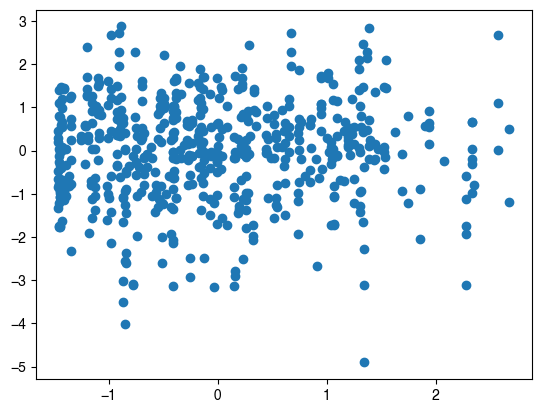

In [165]:
plt.scatter(y,x)

In [172]:
#selecting top value for each gRNA

h1 = []
for i in np.unique(cdk9_CBE_vars['gRNA_id']):
    subset = cdk9_CBE_vars[cdk9_CBE_vars['gRNA_id']==i].sort_values(by='%Reads', ascending=False)
    h1.append(subset.iloc[[0]])

top_only = pd.concat(h1)

In [176]:
#first try with all of the data and some editing cutoff
m3 = pd.merge(top_only, targ_CBE_subset, on='gRNA_id')

#and merge with consurf
CDK9_consurf = pd.read_csv('consurf/P50750_A_consurf_grades.txt', sep='\t', header=23)[:372]
CDK9_consurf['Codon'] = [int(i) for i in CDK9_consurf['POS']]

m4 = pd.merge(m3, CDK9_consurf, on='Codon')

In [180]:
read_cutoff =0
m_cutoff = m4[m4['%Reads']>=read_cutoff]
print(f'{len(m_cutoff)}/{len(m4)}')

x,y = list(m_cutoff['LFC_median_DMSO']), list(m_cutoff[' SCORE'])
scipy.stats.pearsonr(x,y)

689/689


PearsonRResult(statistic=0.010151488672839033, pvalue=0.7902488237422698)

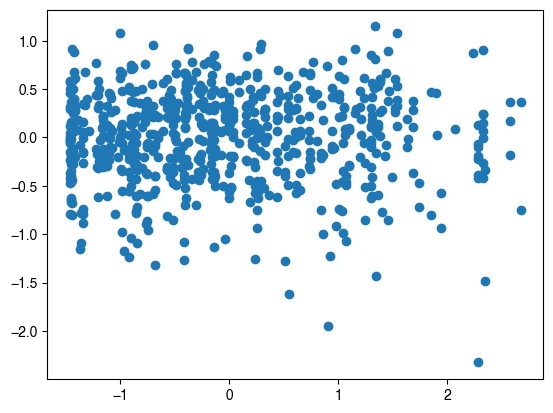

In [181]:
plt.scatter(y,x)

<BarContainer object of 14 artists>

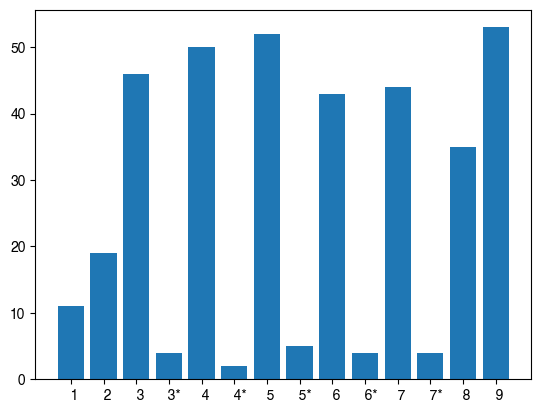

In [187]:
u, c = np.unique(CDK9_consurf['COLOR'], return_counts=True)

plt.bar(u,c)

(array([ 0.,  0.,  0.,  0.,  0.,  0.,  0.,  0.,  0.,  0.,  0.,  0.,  0.,
         0.,  0.,  0.,  0.,  0.,  0.,  0.,  0.,  0.,  0.,  0.,  0., 22.,
         4.,  8.,  4., 10.,  6.,  9.,  5.,  7.,  7.,  6., 10., 12.,  5.,
         5.,  9., 11., 12.,  7.,  5., 11., 11., 11.,  9.,  5.,  6.,  3.,
         9.,  8.,  7.,  8.,  3.,  5.,  6.,  8.,  2.,  7.,  4.,  4.,  4.,
         3.,  7.,  4.,  4.,  8.,  5.,  7.,  5.,  4.,  5.,  0.,  2.,  3.,
         1.,  1.,  4.,  2.,  0.,  1.,  0.,  1.,  2.,  2.,  1.,  1.,  0.,
         2.,  1.,  1.,  0.,  0.,  0.,  0.,  0.]),
 array([-3.        , -2.93939394, -2.87878788, -2.81818182, -2.75757576,
        -2.6969697 , -2.63636364, -2.57575758, -2.51515152, -2.45454545,
        -2.39393939, -2.33333333, -2.27272727, -2.21212121, -2.15151515,
        -2.09090909, -2.03030303, -1.96969697, -1.90909091, -1.84848485,
        -1.78787879, -1.72727273, -1.66666667, -1.60606061, -1.54545455,
        -1.48484848, -1.42424242, -1.36363636, -1.3030303 , -1.24242424,
 

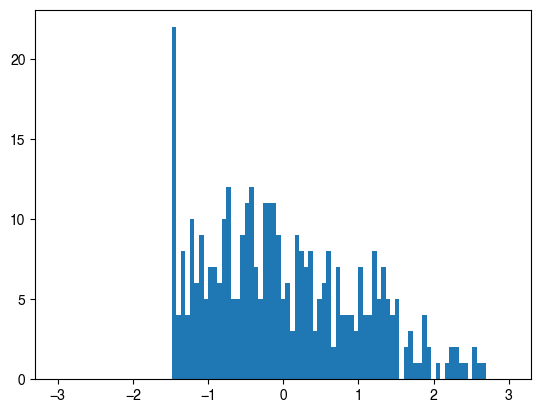

In [189]:
plt.hist(CDK9_consurf[' SCORE'], np.linspace(-3,3,100))

In [193]:
CDK9_consurf.sort_values(by=' SCORE')[:40]

,POS,SEQ,ATOM,SCORE,COLOR,CONFIDENCE INTERVAL,B/E,F/S,MSA DATA,RESIDUE VARIETY,Codon
153,154,N,ASN:154:A,-1.464,9,"-1.497, -1.467 9,9",e,f,150/150,N,154
65,66,E,GLU:66:A,-1.462,9,"-1.497, -1.467 9,9",e,f,146/150,E,66
220,221,E,GLU:221:A,-1.462,9,"-1.497, -1.467 9,9",e,f,149/150,E,221
47,48,K,LYS:48:A,-1.460,9,"-1.497, -1.467 9,9",e,f,144/150,K,48
45,46,A,ALA:46:A,-1.460,9,"-1.497, -1.467 9,9",b,s,144/150,A,46
32,33,V,VAL:33:A,-1.459,9,"-1.497, -1.467 9,9",b,s,143/150,V,33
147,148,R,ARG:148:A,-1.458,9,"-1.497, -1.467 9,9",e,f,150/150,R,148
146,147,H,HIS:147:A,-1.458,9,"-1.497, -1.467 9,9",e,f,150/150,H,147
210,211,D,ASP:211:A,-1.458,9,"-1.497, -1.467 9,9",b,s,150/150,D,211
197,198,E,GLU:198:A,-1.453,9,"-1.497, -1.467 9,9",e,f,150/150,"E 87%, D 12%",198


In [196]:
CDK9_consurf[100:150]

,POS,SEQ,ATOM,SCORE,COLOR,CONFIDENCE INTERVAL,B/E,F/S,MSA DATA,RESIDUE VARIETY,Codon
100,101,L,LEU:101:A,-0.852,8,"-0.981, -0.764 8,7",b,,150/150,"L 66%, M 22%, I 4%, F 4%, V 2%, A <1%",101
101,102,V,VAL:102:A,-1.092,8,"-1.209, -1.029 9,8",b,,150/150,"V 86%, I 10%, A 2%, F <1%",102
102,103,F,PHE:103:A,-0.726,7,"-0.877, -0.639 8,7",b,,150/150,"F 66%, M 16%, L 10%, T 3%, Y 2%, C <1%",103
103,104,D,ASP:104:A,-1.093,8,"-1.209, -1.029 9,8",e,f,150/150,"E 76%, D 13%, P 8%, G 1%, A <1%",104
104,105,F,PHE:105:A,-0.305,6,"-0.497, -0.133 7,5",b,,150/150,"Y 58%, F 30%, L 5%, H 2%, C 2%, A <1%",105
105,106,C,CYS:106:A,-0.412,6,"-0.570, -0.331 7,6",b,,150/150,"M 44%, L 23%, V 14%, C 10%, I 4%, A 2%, F 1...",106
106,107,E,GLU:107:A,0.147,5,"-0.133, 0.269 5,5",e,,150/150,"E 36%, D 33%, P 6%, S 5%, Q 3%, K 3%, A 2...",107
107,108,H,HIS:108:A,-0.338,6,"-0.570, -0.237 7,6",e,,150/150,"H 45%, T 12%, S 10%, Q 8%, M 6%, V 2%, E 2...",108
108,109,D,ASP:109:A,-1.367,9,"-1.467, -1.335 9,9",e,f,150/150,"D 94%, N 2%, T 1%, E <1%, G <1%",109
109,110,L,LEU:110:A,-1.219,9,"-1.335, -1.166 9,9",b,s,150/150,"L 94%, V 2%, M 2%",110


In [302]:
os.listdir('/Volumes/sanchezrivera/samgould/250327San/work')

['tmp',
 'singularity',
 'collect-file',
 'ba',
 '5a',
 '09',
 '39',
 'c4',
 '00',
 '84',
 'd2',
 '03',
 'd1',
 '94',
 '58',
 '8e',
 '37',
 '8f',
 '47',
 '1c',
 '55',
 '.DS_Store',
 '._.DS_Store',
 '81',
 '3c',
 'df',
 '38',
 '97',
 'ab',
 '76',
 '2c',
 '14',
 '2a',
 'ff',
 '69',
 'dd',
 '0a',
 '36',
 '9d',
 'd0',
 '13',
 '6f',
 '71',
 '49',
 'bb',
 'f0',
 '66',
 '70',
 'c0',
 '50',
 '54',
 '5c',
 '0b',
 '7f',
 '26']

In [ ]:
a = pd.read_csv('/Users/samgould/Desktop/FSR Lab/Protocols/RNA-seq-analysis/L156F_analysis/RNA_sample_table.csv')

a = a[:36]
#a[['sample', 'fastq_1', 'fastq_2']].to_csv('/Users/samgould/Desktop/FSR Lab/Protocols/RNA-seq-analysis/L156F_analysis/RNA_sample_table.csv', index=False)
a['strandedness'] = 'auto'
#a.to_csv('/Users/samgould/Desktop/FSR Lab/Protocols/RNA-seq-analysis/L156F_analysis/RNA_sample_table.csv', index=False)

# Stop codons

In [307]:
CBE_editing = pd.read_csv('CBE_editing/all_samples_combined_HGVSp_only.zip')
ABE_editing = pd.read_csv('ABE_screen_data/ABE_editing/ABE_all_samples_combined_HGVSp_only.zip')



In [309]:
idx_h = []
for i, val in CBE_editing.iterrows():
    if '*' in val['HGVSp']:
        idx_h.append(i)
    else:
        continue

In [336]:
stop_inc = CBE_editing.iloc[idx_h]
stop_inc[stop_inc['%Reads']>=70].sort_values(by='%Reads', ascending=False)[:20]

,gRNA_id,HGVSp,#Reads,%Reads
657188,gRNA_CDK19_targ_6623,Q459*,213248,80.772392
318977,gRNA_CDK9_targ_1177,Q131*,118100,78.883738
287078,gRNA_CDK9_targ_1055,Q4*,79683,77.790361
7981,gRNA_CDK7_targ_24,Q22*,92007,77.774303
374560,gRNA_CDK9_targ_1310,Q271*,72163,77.735048
123030,gRNA_CDK8_targ_538,Q134*,41486,76.716534
362446,gRNA_CDK9_targ_1274,Q230*,248638,76.554408
130041,gRNA_CDK8_targ_567,R166*,89027,76.536937
102439,gRNA_CDK8_targ_460,R29*,228110,75.195480
671197,gRNA_CDK19_targ_6649,Q427*,95543,74.706002


<Axes: xlabel='Gene', ylabel='LFC_median_DMSO'>

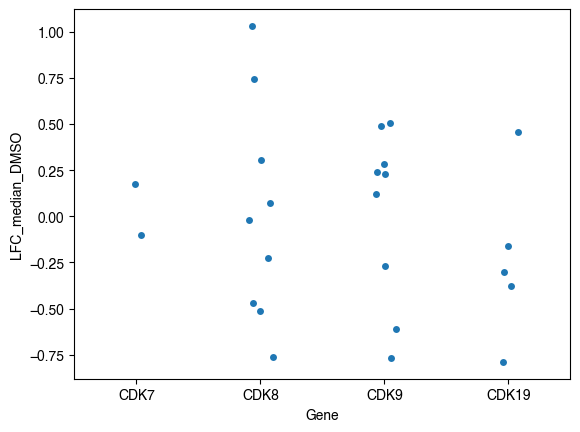

In [337]:
s1 = targ_CBE[targ_CBE['gRNA_id'].isin(stop_inc[stop_inc['%Reads']>=70]['gRNA_id'])]

sns.stripplot(data=s1, x='Gene', y='LFC_median_DMSO')

In [331]:
s1.sort_values(by='LFC_median_T0')

,gRNA_id,Gene,T0_REP1,T0_REP2,T0_REP3,LFC_avg_T0,LFC_median_T0,Plasmid_RPM,p_high_unadjusted_T0,p_low_unadjusted_T0,...,p_high_unadjusted_DMSO,p_low_unadjusted_DMSO,FDR_high_DMSO,FDR_low_DMSO,p_unadjusted_DMSO,FDR_DMSO,WT_perc,Top_HGVSp,Top_HGVSp_%,Codon_1
2219,gRNA_CDK19_targ_6753,CDK19,-4.364619,-6.041134,-3.289710,-4.565154,-4.364619,288.573218,0.998305,0.009022,...,0.980631,0.035645,0.999999,1.0,0.035645,0.999999,22.756860,Q280*,60.768059,280.0
116,gRNA_CDK7_targ_117,CDK7,-2.757009,-3.183321,-3.304844,-3.081725,-3.183321,332.938316,0.985020,0.081707,...,0.988967,0.021021,0.999999,1.0,0.021021,0.999999,14.657751,Q172*,60.756231,172.0
2320,gRNA_CDK19_targ_6854,CDK19,-2.989320,-3.866179,-2.722487,-3.192662,-2.989320,263.362745,0.986225,0.069094,...,0.939335,0.142115,0.999999,1.0,0.142115,0.999999,14.355659,Q122*,65.635125,122.0
2019,gRNA_CDK19_targ_6553,CDK19,-2.406926,-4.681224,-2.753993,-3.280714,-2.753993,196.241527,0.981348,0.061573,...,0.756276,0.299185,0.978892,1.0,0.299185,0.978892,6.930793,W105*,74.528131,105.0
2167,gRNA_CDK19_targ_6701,CDK19,-2.373966,-2.497048,-3.022931,-2.631315,-2.497048,177.220291,0.960674,0.160770,...,0.791143,0.227051,0.994538,1.0,0.227051,0.994538,23.625386,Q372*,60.005503,372.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1610,gRNA_CDK9_targ_1611,CDK9,-0.735002,1.177924,1.392280,0.611734,1.177924,215.369473,0.022428,0.976894,...,0.570202,0.729576,0.875015,1.0,0.570202,0.875015,14.458339,W253*,67.054236,253.0
1275,gRNA_CDK9_targ_1276,CDK9,1.431770,1.276030,2.246927,1.651576,1.431770,483.961057,0.000551,0.999938,...,0.001361,0.999427,0.037904,1.0,0.001361,0.037904,8.404535,Q237*,71.922323,237.0
1615,gRNA_CDK9_targ_1616,CDK9,1.484425,2.117975,-0.732496,0.956635,1.484425,335.365991,0.003272,0.981964,...,0.145831,0.961912,0.442980,1.0,0.145831,0.442980,16.264623,W253*,63.471699,253.0
22,gRNA_CDK7_targ_23,CDK7,1.557744,1.363274,1.751912,1.557644,1.557744,759.462178,0.000799,0.999954,...,0.012452,0.990302,0.099616,1.0,0.012452,0.099616,12.940765,Q22*,72.828171,22.0


In [334]:
library[library['gRNA_id']=='gRNA_CDK19_targ_6753']

,gRNA_id,Gene,protospacer,proto_G+19,chrom,exon,proto_start,proto_end,PAM,PAM_start,...,CDS_hit,ABE_amenable,CBE_amenable,classification,nearest_exon_distance,Pool,Hamming_BC,gRNA_oligo,RE_sites,gRNA_id_OLD
6752,gRNA_CDK19_targ_6753,CDK19,CACTTCAAAAAGACTTTAGA,GACTTCAAAAAGACTTTAGA,6.0,8,110626803.0,110626784.0,AG,110626782.0,...,True,True,True,targeting,NaN,F1-R1,TACAGCAAATAAG,AGGCACTTGCTCGTACGACGAGCGTACACGTCTCACACCGACTTCA...,2,gRNA_525


# misc analysis

In [18]:
targ_CBE[targ_CBE['Top_HGVSp_%']>=50]

,gRNA_id,Gene,T0_REP1,T0_REP2,T0_REP3,LFC_avg_T0,LFC_median_T0,Plasmid_RPM,p_high_unadjusted_T0,p_low_unadjusted_T0,...,p_high_unadjusted_DMSO,p_low_unadjusted_DMSO,FDR_high_DMSO,FDR_low_DMSO,p_unadjusted_DMSO,FDR_DMSO,WT_perc,Top_HGVSp,Top_HGVSp_%,Codon_1
0,gRNA_CDK7_targ_1,CDK7,-0.539859,-1.593971,0.030762,-0.701023,-0.539859,645.734931,0.409171,0.784270,...,0.087344,0.946685,0.318846,1.0,0.087344,0.318846,26.380917,A2V,55.961404,2.0
4,gRNA_CDK7_targ_5,CDK7,0.964827,0.508946,1.353777,0.942517,0.964827,141.472107,0.014325,0.997652,...,0.000066,0.999994,0.013422,1.0,0.000066,0.013422,12.159279,S7F,52.566937,7.0
5,gRNA_CDK7_targ_6,CDK7,1.142084,0.897041,1.717858,1.252328,1.142084,466.060287,0.004006,0.999447,...,0.004394,0.999061,0.060387,1.0,0.004394,0.060387,2.482542,S7F,62.845637,7.0
6,gRNA_CDK7_targ_7,CDK7,0.359945,-1.272144,0.489341,-0.140953,0.359945,465.179921,0.186991,0.900778,...,0.048458,0.971366,0.226139,1.0,0.048458,0.226139,3.402166,S7F_R8W,51.193874,7.0
7,gRNA_CDK7_targ_8,CDK7,0.029009,-1.684378,-1.064570,-0.906646,-1.064570,505.249901,0.487148,0.714179,...,0.802427,0.467661,0.998582,1.0,0.467661,0.998582,14.008911,A9V,51.126253,9.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2401,gRNA_CDK19_targ_6935,CDK19,0.054150,0.833983,-0.894739,-0.002202,0.054150,488.789729,0.150881,0.932704,...,0.038182,0.975298,0.193033,1.0,0.038182,0.193033,24.051804,R29C,52.237207,29.0
2415,gRNA_CDK19_targ_6949,CDK19,-1.918526,-1.984212,-0.102143,-1.334961,-1.918526,467.287463,0.620781,0.539642,...,0.814574,0.447817,0.999999,1.0,0.447817,0.999999,11.150905,R15W,74.815240,15.0
2421,gRNA_CDK19_targ_6955,CDK19,-2.326784,-0.641928,0.838639,-0.710024,-0.641928,191.092721,0.295164,0.705147,...,0.148213,0.964097,0.447096,1.0,0.148213,0.447096,0.065658,A10V_A11V,83.157204,10.0
2422,gRNA_CDK19_targ_6956,CDK19,-0.421622,1.071924,-2.155816,-0.501838,-0.421622,133.095293,0.208615,0.757999,...,0.074957,0.980825,0.294858,1.0,0.074957,0.294858,0.003343,A10V_A11V,59.635573,10.0


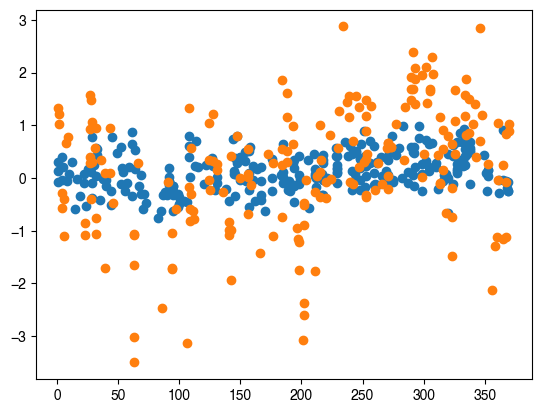

In [29]:
c7a = targ_ABE[(targ_ABE['Top_HGVSp_%']>=50) & (targ_ABE['Gene']=='CDK9')]
c7c = targ_CBE[(targ_CBE['Top_HGVSp_%']>=50) & (targ_CBE['Gene']=='CDK9')]
plt.scatter(c7a['Codon_1'], c7a['LFC_median_T0'])
plt.scatter(c7c['Codon_1'], c7c['LFC_median_T0'])

<Axes: xlabel='Codon_1', ylabel='LFC_median_T0'>

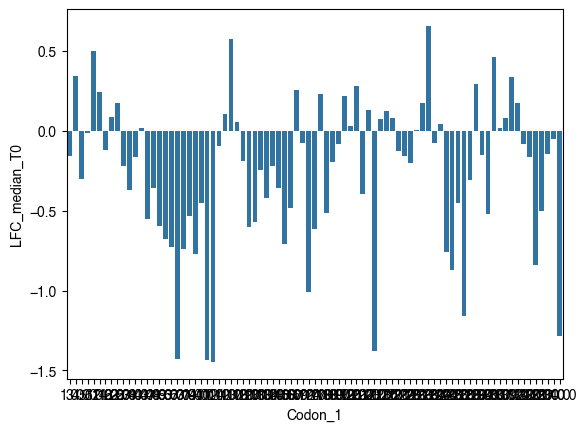

In [44]:
codon_grouped = c7a[['Codon_1', 'LFC_median_T0', 'LFC_median_DMSO']].groupby('Codon_1').mean().reset_index()
codon_grouped.sort_values(by='LFC_median_T0')[:20]

sns.barplot(data=codon_grouped, x='Codon_1', y='LFC_median_T0')

In [45]:
codon_grouped.sort_values(by='LFC_median_T0')[:20]


,Codon_1,LFC_median_T0,LFC_median_DMSO
24,102.0,-1.446407,-2.357180
23,101.0,-1.437478,-2.019529
18,57.0,-1.426480,-2.090915
51,203.0,-1.378424,-1.332425
82,340.0,-1.282724,-1.551969
66,250.0,-1.155950,-2.428994
40,172.0,-1.008534,-1.248275
64,246.0,-0.869222,-0.346915
78,320.0,-0.841047,-1.524476
21,74.0,-0.772797,-1.578436


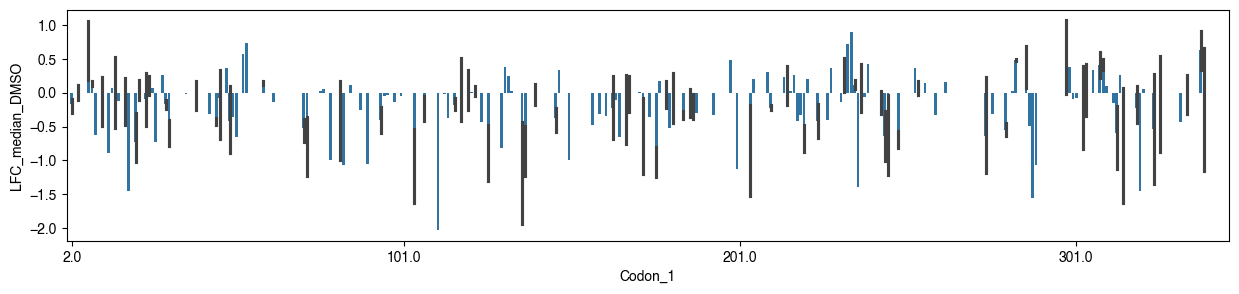

In [68]:
c7a = targ_ABE[(targ_ABE['Top_HGVSp_%']>=10) & (targ_ABE['Gene']=='CDK7')]
c7c = targ_CBE[(targ_CBE['Top_HGVSp_%']>=10) & (targ_CBE['Gene']=='CDK7')]

j = np.unique(c7c['Codon_1'])
missing = []
for i in range(1,347):
    if i in j:
        continue
    else:
        missing.append(i)

missing_df = pd.DataFrame(dict(zip(['Codon_1', 'LFC_median_DMSO'],[missing, np.zeros(len(missing))])))
c7a2 = pd.concat((c7c, missing_df))

fig, ax = plt.subplots(figsize=(15,3))
g = sns.barplot(data=c7a2, x='Codon_1', y='LFC_median_DMSO')

g.set_xticks([1,100,200,300])

# Taking into account editing spectrum
- Need to take into account not just top HGVSp

In [76]:
CBE_editing = pd.read_csv('CBE_editing/all_samples_combined_HGVSp_only.zip')
ABE_editing = pd.read_csv('ABE_screen_data/ABE_editing/ABE_all_samples_combined_HGVSp_only.zip')

CBE_high_edit = CBE_editing[(CBE_editing['HGVSp']!='WT')]
ABE_high_edit = ABE_editing[(ABE_editing['HGVSp']!='WT')]

In [80]:
guides = np.unique(CBE_high_edit['gRNA_id'])
len(guides)

2439

In [82]:
edit_df = CBE_high_edit

In [118]:
import re
def extract_numbers(text):
    """Extracts all numbers from the given text."""
    return [int(i) for i in re.findall(r'\d+', text)] 

def edit_full(edit_df):
    cod_holder = []
    var_holder = []

    guides = np.unique(edit_df['gRNA_id'])

    for guide in guides:

        aa = edit_df[edit_df['gRNA_id']==guide]

        hg = []
        num_reads_hg = []
        codons = []
        num_codon_reads = []

        for i, val in aa.iterrows():
            num_reads = val['#Reads']
            h = val['HGVSp']
            spl = h.split('_')
            cod = extract_numbers(h)

            for k in spl:
                hg.append(k)
                num_reads_hg.append(num_reads)
            
            for j in cod:
                codons.append(j)
                num_codon_reads.append(num_reads)

        hg_df = pd.DataFrame(dict(zip(['HGVSp', '#Reads'], [hg, num_reads_hg])))
        cod_df = pd.DataFrame(dict(zip(['Codon', '#Reads'], [codons, num_codon_reads])))


        aa2 = hg_df.groupby(by='HGVSp').sum().sort_values(by='#Reads', ascending=False).reset_index()
        bb2 = cod_df.groupby(by='Codon').sum().sort_values(by='#Reads', ascending=False).reset_index()

        #divide by original number of reads
        aa2['%Reads'] = 100*aa2['#Reads']/sum(aa['#Reads'])
        bb2['%Reads'] = 100*bb2['#Reads']/sum(aa['#Reads'])

        #perform editing cutoff afterward
        #aa3 = aa2[aa2['%Reads']>=edit_cutoff]
        #bb3 = bb2[bb2['%Reads']>=edit_cutoff]
        aa2['gRNA_id']=guide
        bb2['gRNA_id']=guide
        cod_holder.append(bb2)
        var_holder.append(aa2)

    c = pd.concat(cod_holder)
    v = pd.concat(var_holder)

    return c, v

In [119]:
c_abe, v_abe = edit_full(ABE_high_edit)
c_cbe, v_cbe = edit_full(CBE_high_edit)

In [208]:
v_abe[['gRNA_id', '#Reads']].groupby('gRNA_id').sum().sort_values(by='#Reads')[:40]

,#Reads
gRNA_id,
gRNA_CDK19_targ_6661,2
gRNA_CDK19_targ_6662,23
gRNA_CDK19_targ_6667,58
gRNA_CDK7_targ_226,60
gRNA_CDK19_targ_6670,67
gRNA_CDK7_targ_91,73
gRNA_CDK19_targ_6659,80
gRNA_CDK19_targ_6665,83
gRNA_CDK19_targ_6664,93


In [136]:
v_abe['Codon'] = [extract_numbers(i)[0] for i in v_abe['HGVSp']]
v_cbe['Codon'] = [extract_numbers(i)[0] for i in v_cbe['HGVSp']]
v_abe['Gene'] = [i.split('_')[1] for i in v_abe['gRNA_id']]
v_cbe['Gene'] = [i.split('_')[1] for i in v_cbe['gRNA_id']]

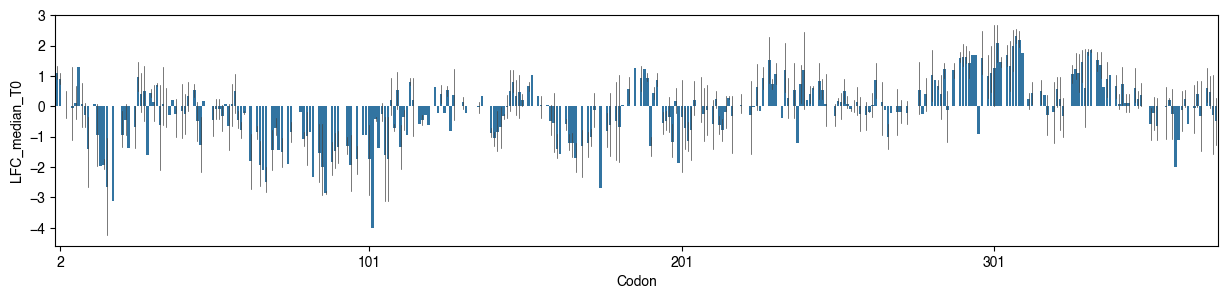

In [ ]:
edit_cutoff=20
gene = 'CDK9'
cut_cbe = v_cbe[(v_cbe['Gene']==gene) & (v_cbe['%Reads']>=edit_cutoff)]
cut_abe = v_abe[(v_abe['Gene']==gene) & (v_abe['%Reads']>=edit_cutoff)]

c7a = targ_ABE[(targ_ABE['Gene']==gene)]
c7c = targ_CBE[(targ_CBE['Gene']==gene)]

#start with CBE analysis
c7c2 = pd.merge(cut_cbe, c7c, on='gRNA_id')


j = np.unique(c7c2['Codon'])
missing = []
for i in range(1,372): #ADJUST TO CDK7 GENE LENGTH
    if i in j:
        continue
    else:
        missing.append(i)

missing_df = pd.DataFrame(dict(zip(['Codon', 'LFC_median_T0'],[missing, np.zeros(len(missing))])))
c7a2 = pd.concat((c7c2, missing_df))

fig, ax = plt.subplots(figsize=(15,3))
g = sns.barplot(data=c7a2, x='Codon', y='LFC_median_T0', errwidth=.5)

g.set_xticks([1,100,200,300])

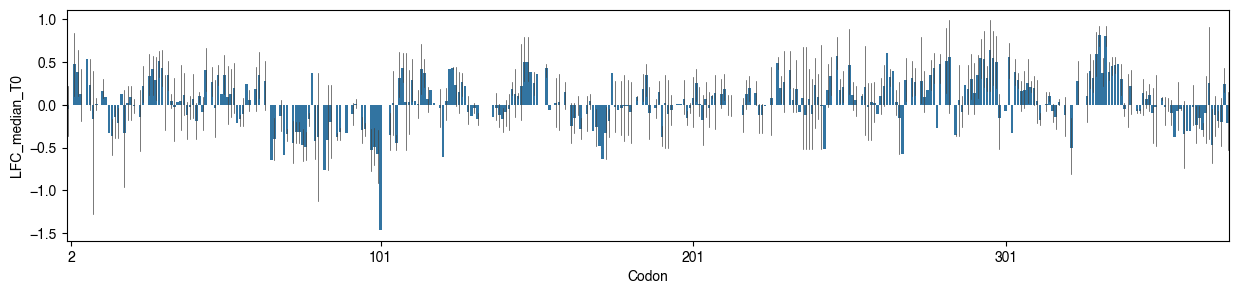

In [166]:
#start with CBE analysis
c7c2 = pd.merge(cut_abe, c7a, on='gRNA_id')


j = np.unique(c7c2['Codon'])
missing = []
for i in range(1,372):
    if i in j:
        continue
    else:
        missing.append(i)

missing_df = pd.DataFrame(dict(zip(['Codon', 'LFC_median_T0'],[missing, np.zeros(len(missing))])))
c7a2 = pd.concat((c7c2, missing_df))

fig, ax = plt.subplots(figsize=(15,3))
g = sns.barplot(data=c7a2, x='Codon', y='LFC_median_T0', errwidth=.5)

g.set_xticks([1,100,200,300])

PearsonRResult(statistic=0.5577705959583672, pvalue=1.834801262542755e-14)

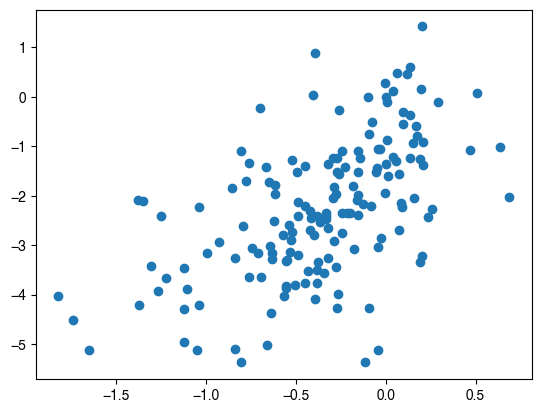

In [200]:
edit_cutoff=20
gene = 'CDK7'
cut_cbe = v_cbe[(v_cbe['Gene']==gene) & (v_cbe['%Reads']>=edit_cutoff)]
cut_abe = v_abe[(v_abe['Gene']==gene) & (v_abe['%Reads']>=edit_cutoff)]

c7a = targ_ABE[(targ_ABE['Gene']==gene)]
c7c = targ_CBE[(targ_CBE['Gene']==gene)]

c7c2 = pd.merge(cut_cbe, c7c, on='gRNA_id')
c7a2 = pd.merge(cut_abe, c7a, on='gRNA_id')


c_grouped = c7c2[['Codon', 'LFC_median_T0', 'LFC_median_DMSO']].groupby('Codon').mean().reset_index()
a_grouped = c7a2[['Codon', 'LFC_median_T0', 'LFC_median_DMSO']].groupby('Codon').mean().reset_index().rename(columns={'LFC_median_T0':'LFC_median_T0_ABE', 'LFC_median_DMSO':'LFC_median_DMSO_ABE'})

m = pd.merge(c_grouped, a_grouped, on='Codon')

x,y = m['LFC_median_T0_ABE'], m['LFC_median_T0']
plt.scatter(x,y)
scipy.stats.pearsonr(x,y)

In [178]:
scipy.stats.pearsonr(m['LFC_median_T0'], m['LFC_median_T0_ABE'])

PearsonRResult(statistic=0.5240732871779485, pvalue=4.036328364504062e-18)

In [ ]:

c7a = targ_ABE[(targ_ABE['Top_HGVSp_%']>=10) & (targ_ABE['Gene']=='CDK7')]
c7c = targ_CBE[(targ_CBE['Top_HGVSp_%']>=10) & (targ_CBE['Gene']=='CDK7')]

j = np.unique(c7c['Codon_1'])
missing = []
for i in range(1,347):
    if i in j:
        continue
    else:
        missing.append(i)

missing_df = pd.DataFrame(dict(zip(['Codon_1', 'LFC_median_DMSO'],[missing, np.zeros(len(missing))])))
c7a2 = pd.concat((c7c, missing_df))

fig, ax = plt.subplots(figsize=(15,3))
g = sns.barplot(data=c7a2, x='Codon_1', y='LFC_median_DMSO')

g.set_xticks([1,100,200,300])

,Codon,#Reads,%Reads,gRNA_id
0,501,5319,66.880422,gRNA_CDK19_targ_6273
1,499,2330,29.297121,gRNA_CDK19_targ_6273
2,500,2140,26.908085,gRNA_CDK19_targ_6273
3,498,2038,25.625550,gRNA_CDK19_targ_6273
4,502,1669,20.985792,gRNA_CDK19_targ_6273


In [106]:
v[v['gRNA_id']=='gRNA_CDK19_targ_6279']

,HGVSp,#Reads,%Reads,gRNA_id
0,A499T,73475,79.294417,gRNA_CDK19_targ_6279
1,Q498H,17813,19.223837,gRNA_CDK19_targ_6279
2,A499S,8604,9.285460,gRNA_CDK19_targ_6279
3,H494Q,8374,9.037243,gRNA_CDK19_targ_6279
4,A499P,3349,3.614250,gRNA_CDK19_targ_6279
...,...,...,...,...
83,Q498D,1,0.001079,gRNA_CDK19_targ_6279
84,Q498A,1,0.001079,gRNA_CDK19_targ_6279
85,P495W,1,0.001079,gRNA_CDK19_targ_6279
86,H500E,1,0.001079,gRNA_CDK19_targ_6279


In [74]:
len(missing_df)/342

0.543859649122807

In [67]:
len(np.unique(targ_CBE[(targ_CBE['Top_HGVSp_%']>=50) & (targ_CBE['Gene']=='CDK9')]['Codon_1']))

113

In [69]:
targ_CBE[(targ_CBE['Codon_1']==144) & (targ_CBE['Gene']=='CDK7')]

,gRNA_id,Gene,T0_REP1,T0_REP2,T0_REP3,LFC_avg_T0,LFC_median_T0,Plasmid_RPM,p_high_unadjusted_T0,p_low_unadjusted_T0,...,p_high_unadjusted_DMSO,p_low_unadjusted_DMSO,FDR_high_DMSO,FDR_low_DMSO,p_unadjusted_DMSO,FDR_DMSO,WT_perc,Top_HGVSp,Top_HGVSp_%,Codon_1


In [71]:
targ_ABE[(targ_ABE['Codon_1']==25) & (targ_ABE['Gene']=='CDK9')]

,gRNA_id,Gene,T0_REP1,T0_REP2,T0_REP3,LFC_avg_T0,LFC_median_T0,Plasmid_RPM,p_high_unadjusted_T0,p_low_unadjusted_T0,...,p_high_unadjusted_DMSO,p_low_unadjusted_DMSO,FDR_high_DMSO,FDR_low_DMSO,p_unadjusted_DMSO,FDR_DMSO,WT_perc,Top_HGVSp,Top_HGVSp_%,Codon_1
1070,gRNA_CDK9_targ_1071,CDK9,0.450091,0.453794,0.200759,0.368215,0.450091,298.123853,0.025321,0.995782,...,0.073508,0.983277,0.370252,0.999986,0.073508,0.370252,3.435889,I25V,37.337003,25.0
1071,gRNA_CDK9_targ_1072,CDK9,0.000752,0.034753,0.351616,0.129040,0.034753,450.373770,0.136091,0.959671,...,0.012995,0.995121,0.155602,0.999986,0.012995,0.155602,3.890512,I25V_Q27R,24.976948,25.0
1402,gRNA_CDK9_targ_1403,CDK9,0.606310,-0.022261,0.169855,0.251301,0.169855,205.391995,0.056750,0.976553,...,0.603672,0.676031,1.000000,0.999986,0.603672,0.999986,2.839230,I25T,68.117601,25.0


In [51]:
j = np.unique(c7a['Codon_1'])
missing = []
for i in range(1,347):
    if i in j:
        continue
    else:
        missing.append(i)

In [52]:
missing

[2,
 7,
 8,
 9,
 10,
 11,
 13,
 15,
 17,
 18,
 19,
 20,
 21,
 23,
 24,
 26,
 28,
 29,
 30,
 31,
 32,
 33,
 34,
 35,
 36,
 37,
 39,
 41,
 42,
 44,
 45,
 46,
 50,
 51,
 52,
 54,
 55,
 56,
 58,
 59,
 60,
 61,
 62,
 64,
 65,
 66,
 67,
 68,
 69,
 70,
 72,
 73,
 75,
 76,
 77,
 78,
 79,
 80,
 81,
 82,
 83,
 84,
 85,
 86,
 87,
 88,
 89,
 90,
 91,
 92,
 93,
 95,
 96,
 97,
 98,
 99,
 100,
 103,
 105,
 106,
 107,
 108,
 109,
 110,
 111,
 114,
 115,
 116,
 119,
 120,
 122,
 123,
 124,
 125,
 126,
 128,
 129,
 130,
 132,
 135,
 136,
 137,
 139,
 140,
 141,
 142,
 143,
 144,
 146,
 147,
 148,
 149,
 150,
 151,
 152,
 153,
 154,
 155,
 156,
 157,
 159,
 160,
 161,
 162,
 163,
 164,
 165,
 166,
 168,
 170,
 171,
 173,
 175,
 176,
 179,
 180,
 181,
 182,
 183,
 184,
 185,
 186,
 187,
 191,
 193,
 194,
 196,
 197,
 198,
 199,
 200,
 204,
 205,
 206,
 207,
 208,
 209,
 211,
 212,
 214,
 215,
 218,
 219,
 220,
 223,
 224,
 225,
 226,
 227,
 229,
 230,
 232,
 234,
 236,
 238,
 239,
 240,
 241,
 243,
 244,


# Alphamissense

In [384]:
ls = os.listdir('alphamissense_scores')
ls = [i for i in ls if '.csv' in i]
n = []
am = []
for i in ls:
    name = i.split('-')[1].split('.')[0]
    alpha = pd.read_csv(f'alphamissense_scores/{i}')[['# Uniprot ACC', 'Entry name', 'Gene name', 'Ensemble id',
       'protein variant', 'is_snv', 'a.a.1', 'position', 'a.a.2',
       'pathogenicity score', 'pathogenicity class']]

    for idx, val in alpha.iterrows():
        alpha.loc[idx, 'HGVSp'] = val['a.a.1'] + str(val['position']) + val['a.a.2']
    n.append(name)
    am.append(alpha)

am_dict = dict(zip(n,am))

In [430]:
edit_cutoff=40

dfh = []
for gene in genes:
    corr_a = []
    corr_b = []
    corr_c = []
    corr_d = []
    for edit_cutoff in range(0,70):
        cdk9_am = am_dict[gene]

        cut_cbe = v_cbe[(v_cbe['Gene']==gene) & (v_cbe['%Reads']>=edit_cutoff)]
        cut_abe = v_abe[(v_abe['Gene']==gene) & (v_abe['%Reads']>=edit_cutoff)]

        c7a = targ_ABE[(targ_ABE['Gene']==gene)]
        c7c = targ_CBE[(targ_CBE['Gene']==gene)]

        #start with CBE analysis
        c7c2 = pd.merge(cut_cbe, c7c, on='gRNA_id')
        a7a2 = pd.merge(cut_abe, c7a, on='gRNA_id')

        alpha_merge_CBE = pd.merge(c7c2, cdk9_am, on='HGVSp')
        alpha_merge_ABE = pd.merge(a7a2, cdk9_am, on='HGVSp')


        a = scipy.stats.pearsonr(alpha_merge_CBE['pathogenicity score'], alpha_merge_CBE['LFC_median_T0']).statistic
        b = scipy.stats.pearsonr(alpha_merge_ABE['pathogenicity score'], alpha_merge_ABE['LFC_median_T0']).statistic
        c = scipy.stats.pearsonr(alpha_merge_CBE['pathogenicity score'], alpha_merge_CBE['LFC_median_DMSO']).statistic
        d = scipy.stats.pearsonr(alpha_merge_ABE['pathogenicity score'], alpha_merge_ABE['LFC_median_DMSO']).statistic
    
        corr_a.append(a)
        corr_b.append(b)
        corr_c.append(c)
        corr_d.append(d)

    d1 = pd.DataFrame(dict(zip(['Edit Threshold', 'CBE T0', 'ABE T0', 'CBE TFinal', 'ABE TFinal'], [list(range(0,70)), corr_a, corr_b, corr_c, corr_d])))
    d1['Gene'] = gene
    dfh.append(d1)


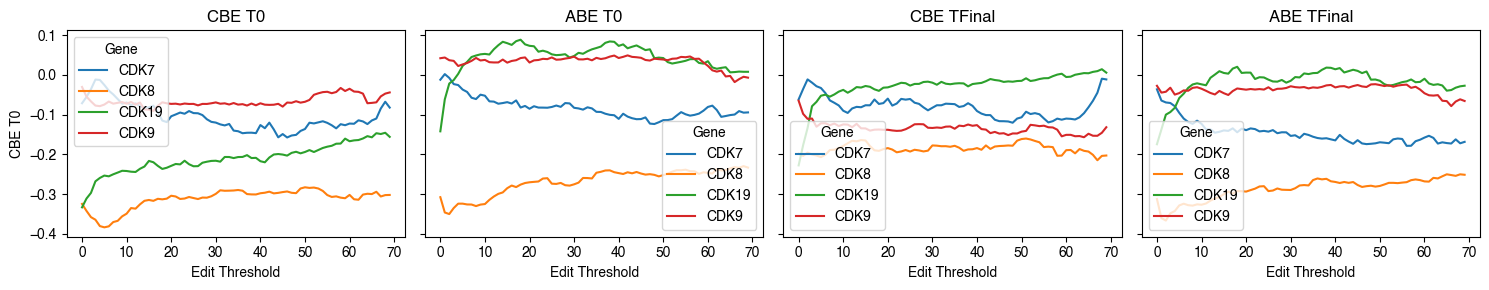

In [433]:
aa = pd.concat(dfh)
fig, ax = plt.subplots(1,4,figsize=(15,3), sharey=True)
sns.lineplot(data=aa, x='Edit Threshold', y='CBE T0', hue='Gene', ax=ax[0])
sns.lineplot(data=aa, x='Edit Threshold', y='ABE T0', hue='Gene', ax=ax[1])
sns.lineplot(data=aa, x='Edit Threshold', y='CBE TFinal', hue='Gene', ax=ax[2])
sns.lineplot(data=aa, x='Edit Threshold', y='ABE TFinal', hue='Gene', ax=ax[3])

ax[0].set_title('CBE T0')
ax[1].set_title('ABE T0')
ax[2].set_title('CBE TFinal')
ax[3].set_title('ABE TFinal')


fig.tight_layout()

In [ ]:
#try same thing with just top vcariants

edit_cutoff=40

dfh2 = []
for gene in genes:
    corr_a = []
    corr_b = []
    corr_c = []
    corr_d = []
    for edit_cutoff in range(0,70):
        cdk9_am = am_dict[gene]

        cut_cbe = targ_CBE[(targ_CBE['Gene']==gene) & (targ_CBE['Top_HGVSp_%']>=edit_cutoff)].rename(columns={'Top_HGVSp':'HGVSp'})
        cut_abe = targ_ABE[(targ_ABE['Gene']==gene) & (targ_ABE['Top_HGVSp_%']>=edit_cutoff)].rename(columns={'Top_HGVSp':'HGVSp'})

        alpha_merge_CBE = pd.merge(cut_cbe, cdk9_am, on='HGVSp')
        alpha_merge_ABE = pd.merge(cut_abe, cdk9_am, on='HGVSp')


        a = scipy.stats.pearsonr(alpha_merge_CBE['pathogenicity score'], alpha_merge_CBE['LFC_median_T0']).statistic
        b = scipy.stats.pearsonr(alpha_merge_ABE['pathogenicity score'], alpha_merge_ABE['LFC_median_T0']).statistic
        c = scipy.stats.pearsonr(alpha_merge_CBE['pathogenicity score'], alpha_merge_CBE['LFC_median_DMSO']).statistic
        d = scipy.stats.pearsonr(alpha_merge_ABE['pathogenicity score'], alpha_merge_ABE['LFC_median_DMSO']).statistic
    
        corr_a.append(a)
        corr_b.append(b)
        corr_c.append(c)
        corr_d.append(d)

    d1 = pd.DataFrame(dict(zip(['Edit Threshold', 'CBE T0', 'ABE T0', 'CBE TFinal', 'ABE TFinal'], [list(range(0,70)), corr_a, corr_b, corr_c, corr_d])))
    d1['Gene'] = gene
    dfh2.append(d1)

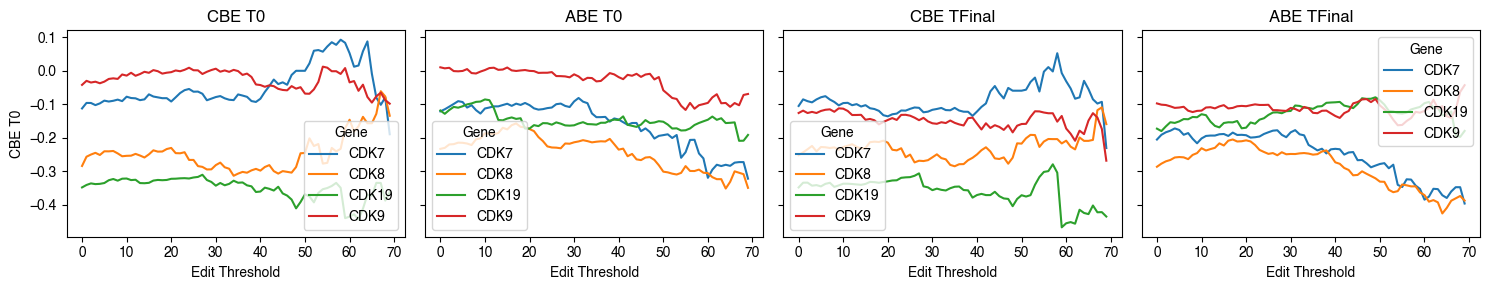

In [432]:
bb = pd.concat(dfh2)
fig, ax = plt.subplots(1,4,figsize=(15,3), sharey=True)
sns.lineplot(data=bb, x='Edit Threshold', y='CBE T0', hue='Gene', ax=ax[0])
sns.lineplot(data=bb, x='Edit Threshold', y='ABE T0', hue='Gene', ax=ax[1])
sns.lineplot(data=bb, x='Edit Threshold', y='CBE TFinal', hue='Gene', ax=ax[2])
sns.lineplot(data=bb, x='Edit Threshold', y='ABE TFinal', hue='Gene', ax=ax[3])

ax[0].set_title('CBE T0')
ax[1].set_title('ABE T0')
ax[2].set_title('CBE TFinal')
ax[3].set_title('ABE TFinal')


fig.tight_layout()

# T0 vs. Tfinal analysis

In [443]:
plasmid_median = np.median(np.asarray(CBE_RPM[['T0_REP1', 'T0_REP2', 'T0_REP3']]), axis=1)

conditions = ['DMSO']

df_holder2 = []
for condition_of_interest in conditions:

#condition_of_interest = 'KI-CDK9d-32_1000nM'
    samp_of_interest = [f'{condition_of_interest}_REP{i}' for i in range(1,4)]

    #calculate log2fc
    lfc_list = []
    for k in samp_of_interest:
        col = CBE_RPM[k]
        lfc = np.log2(col/plasmid_median)

        lfc_list.append(lfc)

    lfc_table = pd.DataFrame(dict(zip(samp_of_interest, lfc_list)))
    lfc_table[f'LFC_avg_{condition_of_interest}_vs_T0'] = np.average(lfc_table[samp_of_interest], axis=1)
    lfc_table[f'LFC_median_{condition_of_interest}_vs_T0'] = np.median(lfc_table[samp_of_interest], axis=1)
    lfc_table['T0_RPM'] = plasmid_median
    ids = CBE_RPM[['gRNA_id', 'gene']]

    LFC_df = pd.concat((ids, lfc_table), axis=1)
    LFC_df = one_sided_FDR(condition_of_interest, LFC_df)
    df_holder2.append(LFC_df)

873


In [447]:
combined_LFC = pd.concat(df_holder2, axis=1)
combined_LFC = combined_LFC.loc[:,~combined_LFC.columns.duplicated()].copy()
combined_LFC = combined_LFC.rename(columns = {'gene':'Gene'})


CBE = pd.read_csv('CBE_master_Z_table.csv')
edit_info = CBE[['gRNA_id', 'WT_perc', 'Top_HGVSp', 'Top_HGVSp_%', 'Codon_1']]
targ_TFinal_v_T0_CBE = pd.merge(combined_LFC, edit_info, on='gRNA_id')

In [448]:
plasmid_median = np.median(np.asarray(ABE_RPM[['T0_REP1', 'T0_REP2', 'T0_REP3']]), axis=1)

conditions = ['DMSO']

df_holder2 = []
for condition_of_interest in conditions:

#condition_of_interest = 'KI-CDK9d-32_1000nM'
    samp_of_interest = [f'{condition_of_interest}_REP{i}' for i in range(1,4)]

    #calculate log2fc
    lfc_list = []
    for k in samp_of_interest:
        col = ABE_RPM[k]
        lfc = np.log2(col/plasmid_median)

        lfc_list.append(lfc)

    lfc_table = pd.DataFrame(dict(zip(samp_of_interest, lfc_list)))
    lfc_table[f'LFC_avg_{condition_of_interest}_vs_T0'] = np.average(lfc_table[samp_of_interest], axis=1)
    lfc_table[f'LFC_median_{condition_of_interest}_vs_T0'] = np.median(lfc_table[samp_of_interest], axis=1)
    lfc_table['T0_RPM'] = plasmid_median
    ids = ABE_RPM[['gRNA_id', 'gene']]

    LFC_df = pd.concat((ids, lfc_table), axis=1)
    LFC_df = one_sided_FDR(condition_of_interest, LFC_df)
    df_holder2.append(LFC_df)

873


In [450]:
targ_TFinal_v_T0_CBE

,gRNA_id,Gene,DMSO_REP1,DMSO_REP2,DMSO_REP3,LFC_avg_DMSO_vs_T0,LFC_median_DMSO_vs_T0,T0_RPM,p_high_unadjusted_DMSO,p_low_unadjusted_DMSO,FDR_high_DMSO,FDR_low_DMSO,p_unadjusted_DMSO,FDR_DMSO,WT_perc,Top_HGVSp,Top_HGVSp_%,Codon_1
0,gRNA_CDK7_targ_1,CDK7,0.452913,0.391422,1.182550,0.675628,0.452913,444.160959,0.594127,0.675407,1.000000,0.999998,0.594127,0.999998,26.380917,A2V,55.961404,2.0
1,gRNA_CDK7_targ_2,CDK7,0.613628,0.559236,0.486642,0.553169,0.559236,307.514849,0.689435,0.620851,1.000000,0.999998,0.620851,0.999998,19.888296,A2V,46.477928,2.0
2,gRNA_CDK7_targ_3,CDK7,0.130941,0.164550,-0.083354,0.070712,0.130941,197.244373,0.875946,0.358137,1.000000,0.999998,0.358137,0.999998,28.020919,A2V,22.804246,2.0
3,gRNA_CDK7_targ_4,CDK7,1.654168,1.521591,2.053343,1.743034,1.654168,260.409709,0.158559,0.961921,0.753110,0.999998,0.158559,0.753110,33.897470,S7F,42.264560,7.0
4,gRNA_CDK7_targ_5,CDK7,0.309874,0.287973,-0.201249,0.132199,0.287973,276.129444,0.851481,0.386216,1.000000,0.999998,0.386216,0.999998,12.159279,S7F,52.566937,7.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2725,gRNA_nt_8935,NT,0.667478,0.981673,0.808218,0.819123,0.808218,153.802409,0.544397,0.752814,1.000000,0.999998,0.544397,0.999998,0.000000,0,0.000000,0.0
2726,gRNA_nt_8936,NT,1.860385,1.990559,1.318431,1.723125,1.860385,71.255085,0.163727,0.960448,0.762755,0.999998,0.163727,0.762755,0.000000,0,0.000000,0.0
2727,gRNA_nt_8937,NT,-2.201288,-2.144486,-1.361889,-1.902554,-2.144486,1314.451536,0.999974,0.000299,1.000000,0.080017,0.000299,0.080017,0.000000,0,0.000000,0.0
2728,gRNA_nt_8938,NT,0.186722,0.331429,0.380045,0.299399,0.331429,217.968636,0.797407,0.487896,1.000000,0.999998,0.487896,0.999998,0.000000,0,0.000000,0.0


In [449]:
combined_LFC = pd.concat(df_holder2, axis=1)
combined_LFC = combined_LFC.loc[:,~combined_LFC.columns.duplicated()].copy()
combined_LFC = combined_LFC.rename(columns = {'gene':'Gene'})


ABE = pd.read_csv('ABE_master_Z_table.csv')
edit_info = ABE[['gRNA_id', 'WT_perc', 'Top_HGVSp', 'Top_HGVSp_%', 'Codon_1']]
targ_TFinal_v_T0_ABE = pd.merge(combined_LFC, edit_info, on='gRNA_id')

In [451]:
#try same thing with just top vcariants

edit_cutoff=40

dfh2 = []
for gene in genes:
    corr_a = []
    corr_b = []
    corr_c = []
    corr_d = []
    for edit_cutoff in range(0,70):
        cdk9_am = am_dict[gene]

        cut_cbe = targ_TFinal_v_T0_CBE[(targ_TFinal_v_T0_CBE['Gene']==gene) & (targ_TFinal_v_T0_CBE['Top_HGVSp_%']>=edit_cutoff)].rename(columns={'Top_HGVSp':'HGVSp'})
        cut_abe = targ_TFinal_v_T0_ABE[(targ_TFinal_v_T0_ABE['Gene']==gene) & (targ_TFinal_v_T0_ABE['Top_HGVSp_%']>=edit_cutoff)].rename(columns={'Top_HGVSp':'HGVSp'})

        alpha_merge_CBE = pd.merge(cut_cbe, cdk9_am, on='HGVSp')
        alpha_merge_ABE = pd.merge(cut_abe, cdk9_am, on='HGVSp')


        a = scipy.stats.pearsonr(alpha_merge_CBE['pathogenicity score'], alpha_merge_CBE['LFC_median_DMSO_vs_T0']).statistic
        b = scipy.stats.pearsonr(alpha_merge_ABE['pathogenicity score'], alpha_merge_ABE['LFC_median_DMSO_vs_T0']).statistic

    
        corr_a.append(a)
        corr_b.append(b)


    d1 = pd.DataFrame(dict(zip(['Edit Threshold', 'CBE T0 v Tfinal', 'ABE T0 v Tfinal',], [list(range(0,70)), corr_a, corr_b,])))
    d1['Gene'] = gene
    dfh2.append(d1)

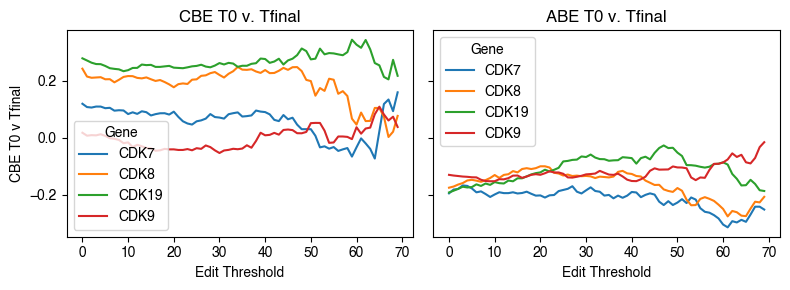

In [454]:
bb = pd.concat(dfh2)
fig, ax = plt.subplots(1,2,figsize=(8,3), sharey=True)
sns.lineplot(data=bb, x='Edit Threshold', y='CBE T0 v Tfinal', hue='Gene', ax=ax[0])
sns.lineplot(data=bb, x='Edit Threshold', y='ABE T0 v Tfinal', hue='Gene', ax=ax[1])


ax[0].set_title('CBE T0 v. Tfinal')
ax[1].set_title('ABE T0 v. Tfinal')



fig.tight_layout()

In [456]:
targ_CBE2

,gRNA_id,Gene,DMSO_REP1,DMSO_REP2,DMSO_REP3,LFC_avg_DMSO_vs_T0,LFC_median_DMSO_vs_T0,T0_RPM,p_high_unadjusted_DMSO,p_low_unadjusted_DMSO,FDR_high_DMSO,FDR_low_DMSO,p_unadjusted_DMSO,FDR_DMSO,WT_perc,Top_HGVSp,Top_HGVSp_%,Codon_1
0,gRNA_CDK7_targ_1,CDK7,0.452913,0.391422,1.182550,0.675628,0.452913,444.160959,0.594127,0.675407,1.000000,0.999998,0.594127,0.999998,26.380917,A2V,55.961404,2.0
1,gRNA_CDK7_targ_2,CDK7,0.613628,0.559236,0.486642,0.553169,0.559236,307.514849,0.689435,0.620851,1.000000,0.999998,0.620851,0.999998,19.888296,A2V,46.477928,2.0
2,gRNA_CDK7_targ_3,CDK7,0.130941,0.164550,-0.083354,0.070712,0.130941,197.244373,0.875946,0.358137,1.000000,0.999998,0.358137,0.999998,28.020919,A2V,22.804246,2.0
3,gRNA_CDK7_targ_4,CDK7,1.654168,1.521591,2.053343,1.743034,1.654168,260.409709,0.158559,0.961921,0.753110,0.999998,0.158559,0.753110,33.897470,S7F,42.264560,7.0
4,gRNA_CDK7_targ_5,CDK7,0.309874,0.287973,-0.201249,0.132199,0.287973,276.129444,0.851481,0.386216,1.000000,0.999998,0.386216,0.999998,12.159279,S7F,52.566937,7.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2434,gRNA_CDK19_targ_6968,CDK19,0.651994,0.680487,0.496711,0.609731,0.651994,154.407338,0.654685,0.655249,1.000000,0.999998,0.654685,0.999998,97.961822,Y3*,0.250701,3.0
2435,gRNA_CDK19_targ_6969,CDK19,1.038863,1.051369,-0.159954,0.643426,1.038863,184.371667,0.590019,0.618029,1.000000,0.999998,0.590019,0.999998,96.817530,F5L,0.932970,5.0
2436,gRNA_CDK19_targ_6970,CDK19,1.297128,1.375350,0.686901,1.119793,1.297128,156.909797,0.355214,0.860153,0.958889,0.999998,0.355214,0.958889,95.112891,F5L,2.656862,5.0
2437,gRNA_CDK19_targ_6971,CDK19,0.269683,0.264387,0.031066,0.188379,0.264387,246.286660,0.840368,0.419498,1.000000,0.999998,0.419498,0.999998,96.727370,Y3*,0.888200,3.0


Text(0.5, 0.98, 'TFinal vs. T0 | Hits Shown with FDR < 0.01 & LFC ≥\xa0-10 & DMSO Control Count ≥ 5')

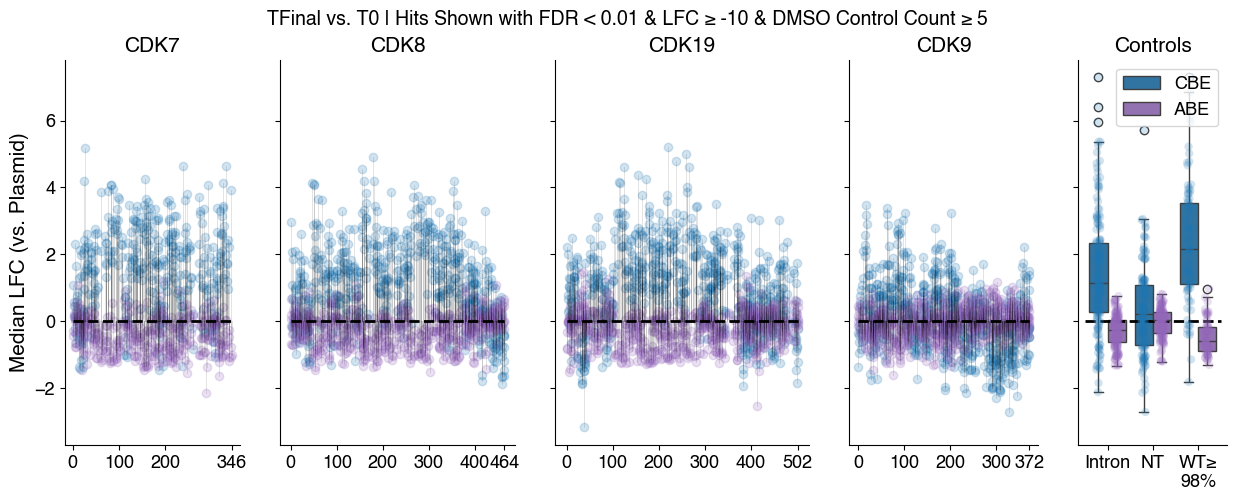

In [462]:
FDR_cutoff = .01
LFC_cutoff = -10
min_DMSO_counts = 5 #here refers to plasmid counts
WT_cutoff = 98

genes = ['CDK7', 'CDK8', 'CDK19', 'CDK9']

targ_CBE2 = targ_TFinal_v_T0_CBE[(targ_TFinal_v_T0_CBE['T0_RPM']>=min_DMSO_counts) & (targ_TFinal_v_T0_CBE['Gene'].isin(genes)) & (targ_TFinal_v_T0_CBE['WT_perc']<WT_cutoff)]
targ_ABE2 = targ_TFinal_v_T0_ABE[(targ_TFinal_v_T0_ABE['T0_RPM']>=min_DMSO_counts) & (targ_TFinal_v_T0_ABE['Gene'].isin(genes)) & (targ_TFinal_v_T0_ABE['WT_perc']<WT_cutoff)]

plot_ABE = True
plot_CBE = True

conditions = ['DMSO', 'A']

true_name = ['TFinal vs. T0', 'DMSO vs. Plasmid']

condition_dict = dict(zip(conditions, true_name))

condition_of_interest = 'DMSO'
name_CBE = f'LFC_median_{condition_of_interest}_vs_T0'
FDR_CBE = f'FDR_high_{condition_of_interest}'

genes = ['CDK7', 'CDK8', 'CDK19', 'CDK9']
ax_dict = {'CDK7':0, 'CDK8':1, 'CDK19':2, 'CDK9':3}

fig, ax = plt.subplots(1,5, figsize=(15,5), sharey=True, width_ratios=[352, 472, 511, 379, 300])

xticks = [[0,100,200,346],
          [0,100,200,300,400,464],
          [0,100,200,300,400,502],
          [0,100,200,300,372]]

#-------plot CBE--------
if plot_CBE == True:
    for i, gene in enumerate(genes):
        s = targ_CBE2[targ_CBE2['Gene']==gene]
        
        x = ax_dict[gene]

        #bb1 = s[(s[name_CBE]<cutoff) | (s[name_CBE]>cutoff_low)]
        #bb2 = s[(s[name_CBE]>=cutoff) | (s[name_CBE]<=cutoff_low)]

        bb1 = s[(s[FDR_CBE]>FDR_cutoff) | ((s[name_CBE]<LFC_cutoff))]
        bb2 = s[(s[FDR_CBE]<=FDR_cutoff) & ((s[name_CBE]>=LFC_cutoff))]

        ax[x].scatter(bb1['Codon_1'], bb1[name_CBE], alpha=.2, color='tab:blue')
        ax[x].scatter(bb2['Codon_1'], bb2[name_CBE], alpha=1, color='tab:blue')

        for iii, val in bb2.iterrows():
            ax[x].plot([val['Codon_1'], val['Codon_1']], [0,val[name_CBE]], linewidth=.4, color='black', alpha=.2)
        for iii, val in bb1.iterrows():
            ax[x].plot([val['Codon_1'], val['Codon_1']], [0,val[name_CBE]], linewidth=.4, color='black', alpha=.2)

        ax[x].spines[['right', 'top']].set_visible(False)
        ax[x].tick_params(axis='both', which='major', labelsize=13)
        ax[x].set_xticks(xticks[i])

        t = list(bb2['Top_HGVSp'])
        x2=list(bb2['Codon_1'])
        y = list(bb2[name_CBE])

        if len(bb2)>0:
            texts = [ax[x].text(x2[i], y[i], t[i], fontsize=8, color='tab:blue', path_effects=[PathEffects.withStroke(linewidth=3,
                                                                                            foreground="w")]) for i in range(len(x2))] #bbox = dict(boxstyle = 'round,pad=0.5', fc = 'white', alpha = .9)

            adjust_text(texts,only_move={'points':'xy', 'texts':'xy'}, ax=ax[x], arrowprops=dict(arrowstyle="-", linewidth=1, alpha=1, color='tab:blue'))

#-----plot ABE-------
if plot_ABE== True:
    for i, gene in enumerate(genes):
        s = targ_ABE2[targ_ABE2['Gene']==gene]
        
        x = ax_dict[gene]

        bb1 = s[(s[FDR_CBE]>FDR_cutoff) | ((s[name_CBE]<LFC_cutoff))]
        bb2 = s[(s[FDR_CBE]<=FDR_cutoff) & ((s[name_CBE]>=LFC_cutoff))]

        ax[x].scatter(bb1['Codon_1'], bb1[name_CBE], alpha=.2, color='tab:purple')
        ax[x].scatter(bb2['Codon_1'], bb2[name_CBE], alpha=1, color='tab:purple')

        for iii, val in bb2.iterrows():
            ax[x].plot([val['Codon_1'], val['Codon_1']], [0,val[name_CBE]], linewidth=.4, color='black', alpha=.2)
        for iii, val in bb1.iterrows():
            ax[x].plot([val['Codon_1'], val['Codon_1']], [0,val[name_CBE]], linewidth=.4, color='black', alpha=.2)


        ax[x].spines[['right', 'top']].set_visible(False)
        ax[x].tick_params(axis='both', which='major', labelsize=13)
        ax[x].set_xticks(xticks[i])

        t = list(bb2['Top_HGVSp'])
        x2=list(bb2['Codon_1'])
        y = list(bb2[name_CBE])

        if len(bb2)>0:
            texts = [ax[x].text(x2[i], y[i], t[i], fontsize=8, color='tab:purple', path_effects=[PathEffects.withStroke(linewidth=3,
                                                                                            foreground="w")]) for i in range(len(x2))] #bbox = dict(boxstyle = 'round,pad=0.5', fc = 'white', alpha = .9)

            adjust_text(texts,only_move={'points':'xy', 'texts':'xy'}, ax=ax[x], arrowprops=dict(arrowstyle="-", linewidth=1, alpha=1, color='tab:purple'))


ax[0].plot([0,346], [0,0], linewidth=2, color='black', linestyle='dashed')
ax[1].plot([0,464], [0,0], linewidth=2, color='black', linestyle='dashed')
ax[2].plot([0,502], [0,0], linewidth=2, color='black', linestyle='dashed')
ax[3].plot([0,372], [0,0], linewidth=2, color='black', linestyle='dashed')

ax[0].set_title('CDK7', fontsize=15)
ax[1].set_title('CDK8', fontsize=15)
ax[2].set_title('CDK19', fontsize=15)
ax[3].set_title('CDK9', fontsize=15)

ax[0].set_ylabel('Median LFC (vs. Plasmid)', fontsize=15)


#-----controls plotting--------
controls_combined = control_maker(targ_TFinal_v_T0_ABE, targ_TFinal_v_T0_CBE, WT_cutoff)
sns.stripplot(data = controls_combined, x='Guide Class', y=name_CBE,hue='Editor', ax=ax[4], palette=['tab:blue', 'tab:purple'], alpha=.2, dodge=True, s=6, legend=False)
sns.boxplot(data = controls_combined, x='Guide Class', y=name_CBE,hue='Editor', ax=ax[4], palette=['tab:blue', 'tab:purple'])

ax[4].plot([-.5,2.5], [0,0], linewidth=2, color='black', linestyle='dashed')

ax[4].spines[['right', 'top']].set_visible(False)
ax[4].tick_params(axis='both', which='major', labelsize=13)
ax[4].set_xlabel('')
ax[4].set_title('Controls', fontsize=15)
ax[4].legend(fontsize=13)


fig.suptitle(f'{condition_dict[condition_of_interest]} | Hits Shown with FDR < {FDR_cutoff} & LFC ≥ {LFC_cutoff} & DMSO Control Count ≥ {min_DMSO_counts}', fontsize=14)


In [472]:
targ_TFinal_v_T0_CBE.sort_values(by='LFC_median_DMSO_vs_T0', ascending=True)[['Gene', 'Top_HGVSp', 'Top_HGVSp_%', 'LFC_median_DMSO_vs_T0', 'T0_RPM', 'FDR_DMSO']][:50]

,Gene,Top_HGVSp,Top_HGVSp_%,LFC_median_DMSO_vs_T0,T0_RPM,FDR_DMSO
2053,CDK19,K37N,11.200977,-3.175770,2590.684859,0.033580
2612,NT,0,0.000000,-2.720508,226.174129,0.016198
1686,CDK9,M327I,42.644711,-2.715228,2041.258242,0.019332
1336,CDK9,P300L_A301V,35.890143,-2.306340,2730.688017,0.081703
1703,CDK9,G346S,52.789943,-2.245188,2485.207419,0.087598
1587,CDK9,E234K,69.602897,-2.159534,3564.518902,0.045732
2727,NT,0,0.000000,-2.144486,1314.451536,0.080017
1661,CDK9,A309T,24.868069,-2.129443,1103.919383,0.080017
2472,CDK7_intron,0,0.000000,-2.125631,1279.937971,0.096805
1539,CDK9,R188H,17.154274,-2.072906,1149.202254,0.045732


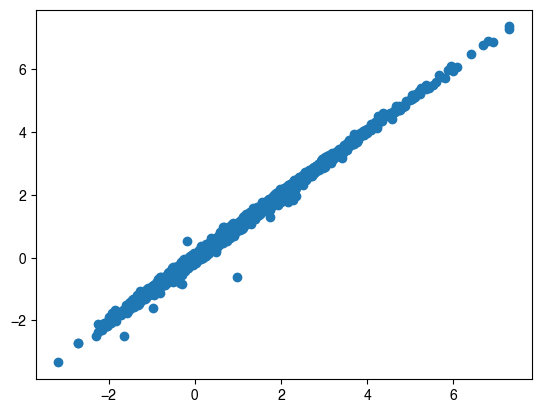

In [475]:
plt.scatter(targ_TFinal_v_T0_CBE['DMSO_REP1'], targ_TFinal_v_T0_CBE['DMSO_REP2'])

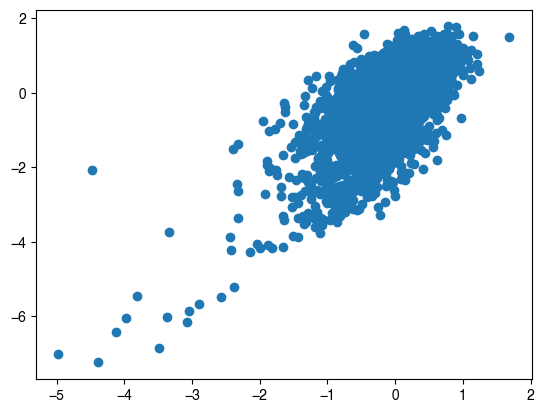

In [489]:
plt.scatter(targ_ABE['DMSO_REP2'], targ_ABE['DMSO_REP3'])